# Visualize nilearn GLM, 2nd level ROI analysis: Valuation (rating, rank regression!)

In [7]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from nilearn import image
from nilearn.image import load_img, math_img, threshold_img
from nilearn.plotting import (
    plot_stat_map, plot_glass_brain, plot_design_matrix,
    plot_anat, plot_img
)

# ---- Set these paths ----
OUTPUT_DIR = Path("/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_rating_parametric")  # <-- edit if needed

# Optional: provide a template background; if None, nilearn will use MNI152 by default in some plots
BG_IMG = None  # e.g. "/path/to/MNI152_T1_2mm_brain.nii.gz"

# Subjects to QC (subset if you want)
SUBJECTS = None  # e.g. ["sub-007", "sub-030"]; None = auto-detect all in OUTPUT_DIR

# Contrasts you wrote in the GLM script
#CONTRASTS = ["Liked", "Disliked", "Neutral", "Liked_gt_Disliked", "Liked_gt_Neutral", "Value"]
CONTRASTS = ["stim", "Value"]


# Display defaults
DISPLAY_MODE = "ortho"
CUT_COORDS = (0, -20, 10)
Z_THRESHOLD = 3.1   # adjust
TOP_N_PEAKS = 10    # for peak table per map

# for anatomy
DERIVATIVES_ROOT = Path("/nfs/roberts/pi/pi_il77/Alex/foodvaluation/foodvaluation_BIDS/derivatives")

def subject_anat_bg(sub: str, ses: str = "1") -> Path | None:
    anat = (
        DERIVATIVES_ROOT
        / sub
        / f"ses-{ses}"
        / "anat"
        / f"{sub}_ses-{ses}_acq-mprage_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"
    )
    return anat if anat.exists() else None


In [8]:
def list_subjects(output_dir: Path):
    if not output_dir.exists():
        print(f"[Error] OUTPUT_DIR does not exist: {output_dir}")
        return []
    subs = sorted([p.name for p in output_dir.glob("sub-*") if p.is_dir()])
    if len(subs) == 0:
        print(f"[Error] Found 0 sub-* folders under: {output_dir}")
        print("        Check that OUTPUT_DIR points to the directory that contains sub-XXX folders.")
    return subs

def find_maps_for_subject(output_dir: Path, sub: str):
    if sub is None:
        raise ValueError("sub is None. SUBJECTS is empty; fix OUTPUT_DIR or set SUB_TO_CHECK manually (e.g., 'sub-002').")
    out = {}
    sub_dir = output_dir / sub
    for contrast in CONTRASTS:
        out.setdefault(contrast, {})
        for maptype in ["z", "t", "effect", "variance"]:
            p = sub_dir / f"{sub}_{contrast}_{maptype}.nii.gz"
            if p.exists():
                out[contrast][maptype] = p
    return out

def find_design_matrices(output_dir: Path, sub: str):
    """Return list of (label, csv_path, png_path) for design matrices."""
    sub_dir = output_dir / sub
    csvs = sorted(sub_dir.glob(f"{sub}_*_design_matrix.csv"))
    results = []
    for csv_path in csvs:
        # label is whatever is between sub_ and _design_matrix.csv
        label = csv_path.name.replace(f"{sub}_", "").replace("_design_matrix.csv", "")
        png_path = sub_dir / f"{sub}_{label}_design_matrix.png"
        results.append((label, csv_path, png_path if png_path.exists() else None))
    return results

if SUBJECTS is None:
    SUBJECTS = list_subjects(OUTPUT_DIR)

print(f"Found {len(SUBJECTS)} subject folders under:\n  {OUTPUT_DIR}")
print("First few:", SUBJECTS[:10])

Found 50 subject folders under:
  /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_rating_parametric
First few: ['sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-010', 'sub-011', 'sub-012']


In [9]:
def load_design_matrix(csv_path: Path) -> pd.DataFrame:
    dm = pd.read_csv(csv_path, index_col=0)
    return dm

def design_qc(dm: pd.DataFrame):
    """Return simple QC diagnostics for a design matrix."""
    # Identify suspicious columns: near-constant, huge variance, etc.
    variances = dm.var(axis=0)
    near_zero = variances[variances < 1e-8].index.tolist()

    # Correlation matrix (excluding constant if present)
    corr = dm.corr()
    # Max absolute correlation off-diagonal
    max_abs_corr = (corr.where(~np.eye(corr.shape[0], dtype=bool)).abs().max().max()
                    if corr.shape[0] > 1 else np.nan)

    return {
        "n_timepoints": dm.shape[0],
        "n_regressors": dm.shape[1],
        "near_zero_var_cols": near_zero,
        "max_abs_corr_offdiag": max_abs_corr,
    }

def show_design(sub: str, label: str, csv_path: Path):
    dm = load_design_matrix(csv_path)
    qc = design_qc(dm)

    fig, ax = plt.subplots(figsize=(max(12, dm.shape[1]*0.35), 6))
    plot_design_matrix(dm, ax=ax)
    ax.set_title(f"{sub} | {label}\n"
                 f"TP={qc['n_timepoints']}  Regr={qc['n_regressors']}  "
                 f"Max|r|={qc['max_abs_corr_offdiag']:.3f}  "
                 f"Near0Var={len(qc['near_zero_var_cols'])}")
    plt.tight_layout()
    plt.show()

    if qc["near_zero_var_cols"]:
        print("Near-zero variance columns (often OK for some confounds, but worth checking):")
        print(qc["near_zero_var_cols"][:50])


In [10]:
def img_basic_stats(img_path: Path):
    img = load_img(str(img_path))
    data = img.get_fdata()
    finite = np.isfinite(data)
    if finite.any():
        mn, mx = float(data[finite].min()), float(data[finite].max())
        mean, std = float(data[finite].mean()), float(data[finite].std())
    else:
        mn = mx = mean = std = np.nan
    return {
        "path": str(img_path),
        "shape": img.shape,
        "n_nan": int(np.size(data) - finite.sum()),
        "min": mn,
        "max": mx,
        "mean": mean,
        "std": std,
    }

def peak_table_from_z(z_img_path: Path, threshold=3.1, top_n=10):
    """
    Simple peak extraction without requiring masking/atlas:
    find top-N voxels by z value above threshold.
    """
    img = load_img(str(z_img_path))
    data = img.get_fdata()
    data = np.where(np.isfinite(data), data, -np.inf)
    mask = data > threshold
    if not np.any(mask):
        return pd.DataFrame(columns=["z", "i", "j", "k"])
    idx = np.argwhere(mask)
    vals = data[mask]
    order = np.argsort(vals)[::-1]
    idx = idx[order][:top_n]
    vals = vals[order][:top_n]
    return pd.DataFrame({"z": vals, "i": idx[:,0], "j": idx[:,1], "k": idx[:,2]})


In [11]:
# Replace plot_contrast_maps with this version (uses subject anat when available)
from IPython.display import display as ipy_display

def plot_contrast_maps(sub: str, contrast: str, maps: dict,
                       z_threshold=3.1, cut_coords=(0, -20, 10),
                       display_mode="ortho", bg_img=None, ses_for_anat="1"):
    if contrast not in maps or "z" not in maps[contrast]:
        print(f"[Missing] {sub} {contrast} z-map not found.")
        return

    z_path = maps[contrast]["z"]
    t_path = maps[contrast].get("t")
    eff_path = maps[contrast].get("effect")
    var_path = maps[contrast].get("variance")

    print(f"\n{sub} | {contrast}")
    print("Z map stats:", img_basic_stats(z_path))
    if t_path:   print("T map stats:", img_basic_stats(t_path))
    if eff_path: print("Effect map stats:", img_basic_stats(eff_path))
    if var_path: print("Variance map stats:", img_basic_stats(var_path))

    z_img = load_img(str(z_path))

    # Prefer subject-specific anat background for non-glassbrain plots
    subj_anat = subject_anat_bg(sub, ses=ses_for_anat)
    bg = subj_anat if subj_anat is not None else bg_img
    if subj_anat is None and bg_img is None:
        print("  [Note] No subject anat found and BG_IMG is None; background may look blank.")

    # Thresholded stat map (with anat background)
    plot_stat_map(
        z_img, bg_img=str(bg) if bg is not None else None,
        threshold=z_threshold, cut_coords=cut_coords, display_mode=display_mode,
        title=f"{sub} | {contrast} | z (thr={z_threshold})"
    )

    # Glass brain (background irrelevant)
    plot_glass_brain(
        z_img, threshold=z_threshold, display_mode="lyrz",
        title=f"{sub} | {contrast} | glass brain (thr={z_threshold})"
    )

    # Unthresholded stat map (with anat background)
    plot_stat_map(
        z_img, bg_img=str(bg) if bg is not None else None,
        threshold=None, cut_coords=cut_coords, display_mode=display_mode,
        title=f"{sub} | {contrast} | z (unthresholded)"
    )

    plt.show()

    peaks = peak_table_from_z(z_path, threshold=z_threshold, top_n=TOP_N_PEAKS)
    if len(peaks) == 0:
        print(f"No voxels above z>{z_threshold}.")
    else:
        print(f"Top peaks above z>{z_threshold}:")
        ipy_display(peaks)

SUB_TO_CHECK = sub-005
Design matrices found: 1


/tmp/ipykernel_3954960/3197795131.py:29: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(dm, ax=ax)


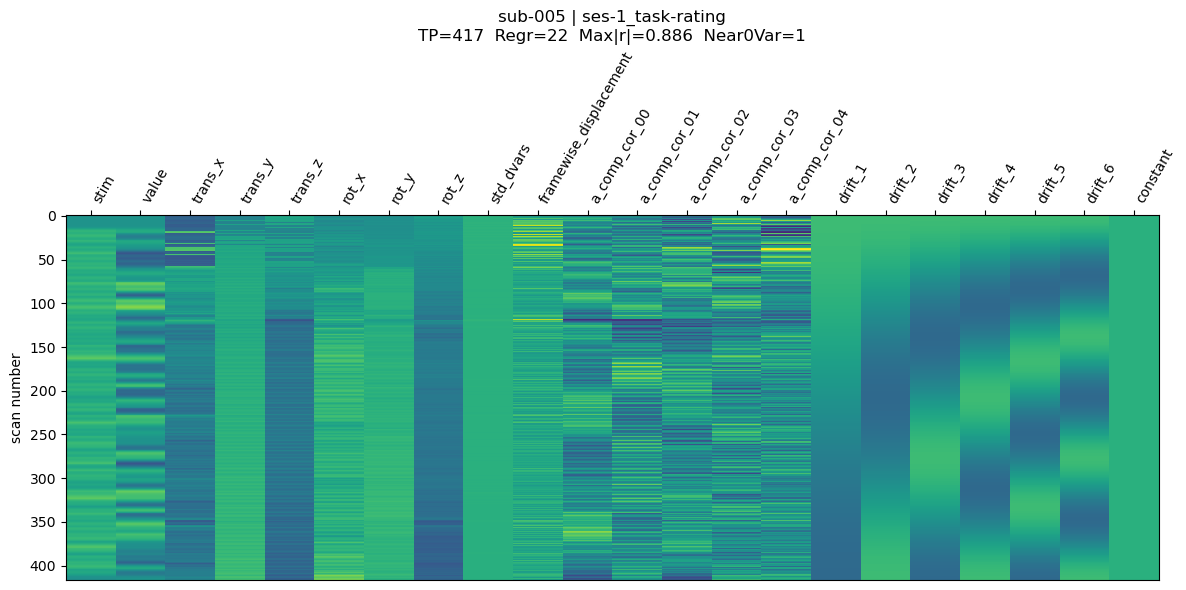

Near-zero variance columns (often OK for some confounds, but worth checking):
['constant']


In [12]:
SUB_TO_CHECK = SUBJECTS[3] if SUBJECTS else None
print("SUB_TO_CHECK =", SUB_TO_CHECK)

maps = find_maps_for_subject(OUTPUT_DIR, SUB_TO_CHECK)

# Design matrices
dms = find_design_matrices(OUTPUT_DIR, SUB_TO_CHECK)
print(f"Design matrices found: {len(dms)}")
for label, csv_path, png_path in dms:
    show_design(SUB_TO_CHECK, label, csv_path)

# Contrast maps
#for c in CONTRASTS:
#    plot_contrast_maps(
#        SUB_TO_CHECK, c, maps,
#        z_threshold=Z_THRESHOLD, cut_coords=CUT_COORDS,
#        display_mode=DISPLAY_MODE, bg_img=BG_IMG,
#        ses_for_anat="1"
#    )


In [6]:
def qc_inventory(output_dir: Path, subjects: list):
    rows = []
    for sub in subjects:
        sub_dir = output_dir / sub
        maps = find_maps_for_subject(output_dir, sub)
        dm = find_design_matrices(output_dir, sub)
        for contrast in CONTRASTS:
            row = {
                "sub": sub,
                "contrast": contrast,
                "has_z": int("z" in maps.get(contrast, {})),
                "has_t": int("t" in maps.get(contrast, {})),
                "has_effect": int("effect" in maps.get(contrast, {})),
                "has_variance": int("variance" in maps.get(contrast, {})),
                "n_design_matrices": len(dm),
                "sub_dir_exists": int(sub_dir.exists()),
            }
            rows.append(row)
    return pd.DataFrame(rows)

inv = qc_inventory(OUTPUT_DIR, SUBJECTS)
inv.head()

print("\nMissing z-maps (by contrast):")
missing = inv[inv["has_z"] == 0].groupby("contrast")["sub"].count().sort_values(ascending=False)
print(missing)

print("\nSubjects with 0 design matrices saved:")
print(inv.groupby("sub")["n_design_matrices"].max().loc[lambda s: s==0])




Missing z-maps (by contrast):
Series([], Name: sub, dtype: int64)

Subjects with 0 design matrices saved:
Series([], Name: n_design_matrices, dtype: int64)


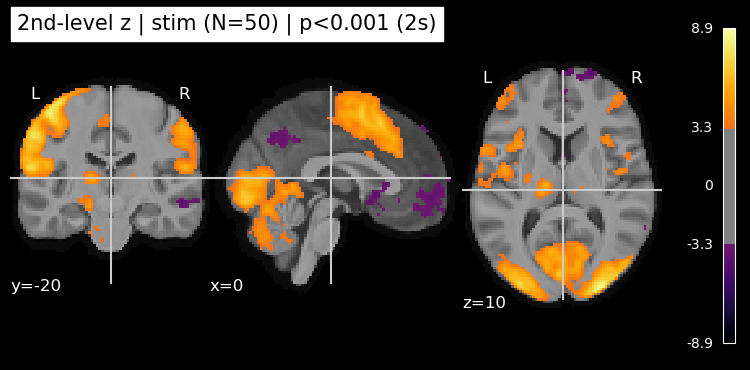

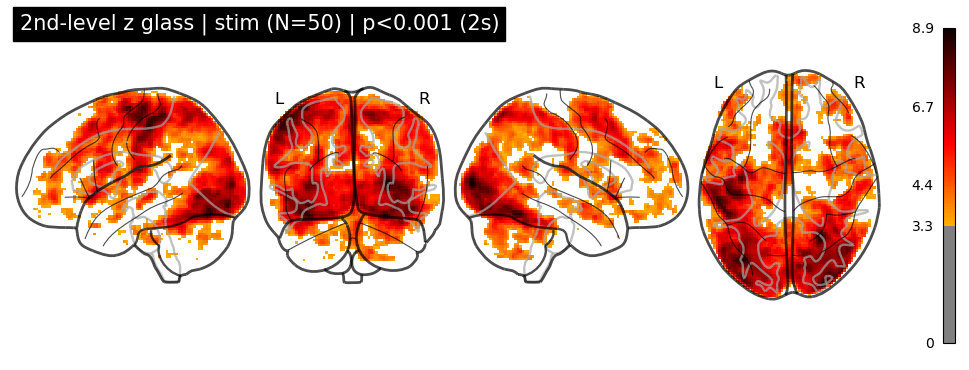

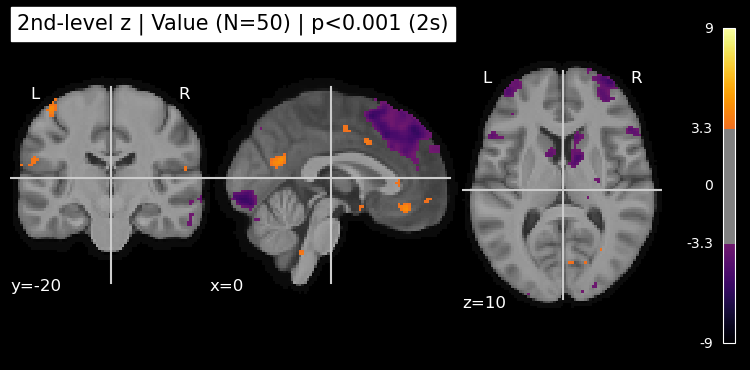

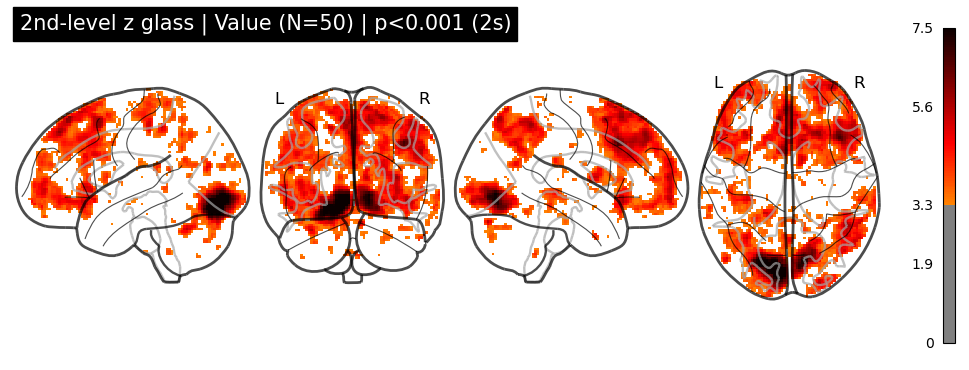

In [7]:
from pathlib import Path
import pandas as pd
from scipy.stats import norm

from nilearn.image import load_img
from nilearn.glm.second_level import SecondLevelModel
from nilearn.plotting import plot_stat_map, plot_glass_brain
import matplotlib.pyplot as plt

MEAN_ANAT = Path("/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/sub_average.nii.gz")
BG_IMG = str(MEAN_ANAT) if MEAN_ANAT.exists() else BG_IMG

def collect_existing_zmaps(output_dir: Path, subjects: list, contrast: str):
    paths = []
    for sub in subjects:
        p = output_dir / sub / f"{sub}_{contrast}_z.nii.gz"
        if p.exists():
            paths.append(str(p))
    return paths

def p_to_z(p, two_sided=True):
    return norm.isf(p / 2.0) if two_sided else norm.isf(p)

P_THR_MAIN  = 0.001
P_THR_GLASS = 0.001
TWO_SIDED = True

Z_THR_MAIN  = p_to_z(P_THR_MAIN,  two_sided=TWO_SIDED)
Z_THR_GLASS = p_to_z(P_THR_GLASS, two_sided=TWO_SIDED)

for contrast in CONTRASTS:
    paths = collect_existing_zmaps(OUTPUT_DIR, SUBJECTS, contrast)
    if not paths:
        print(f"No z-maps found for contrast={contrast}")
        continue

    imgs = [load_img(p) for p in paths]

    design_matrix = pd.DataFrame({"intercept": [1] * len(imgs)})

    slm = SecondLevelModel(smoothing_fwhm=None)
    slm = slm.fit(imgs, design_matrix=design_matrix)

    z_map = slm.compute_contrast(second_level_contrast="intercept", output_type="z_score")

    plot_stat_map(
        z_map, bg_img=BG_IMG, cmap='inferno', threshold=Z_THR_MAIN,
        cut_coords=CUT_COORDS, display_mode=DISPLAY_MODE,
        title=f"2nd-level z | {contrast} (N={len(imgs)}) | p<{P_THR_MAIN} ({'2s' if TWO_SIDED else '1s'})"
    )
    plot_glass_brain(
        z_map, threshold=Z_THR_GLASS, display_mode="lyrz",
        title=f"2nd-level z glass | {contrast} (N={len(imgs)}) | p<{P_THR_GLASS} ({'2s' if TWO_SIDED else '1s'})"
    )
    plt.show()

z_map.to_filename(str(OUTPUT_DIR / f"secondlevel_{contrast}_z.nii.gz"))

## Making ROIs

Input Z map: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/secondlevel_Value_z.nii.gz
Uncorrected p<0.001 (two-sided) => |Z| >= 3.291
Positive clusters: 74 | Negative clusters: 113
ROI mask saved to: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/roi_mask_Value_uncorrected_z.nii.gz


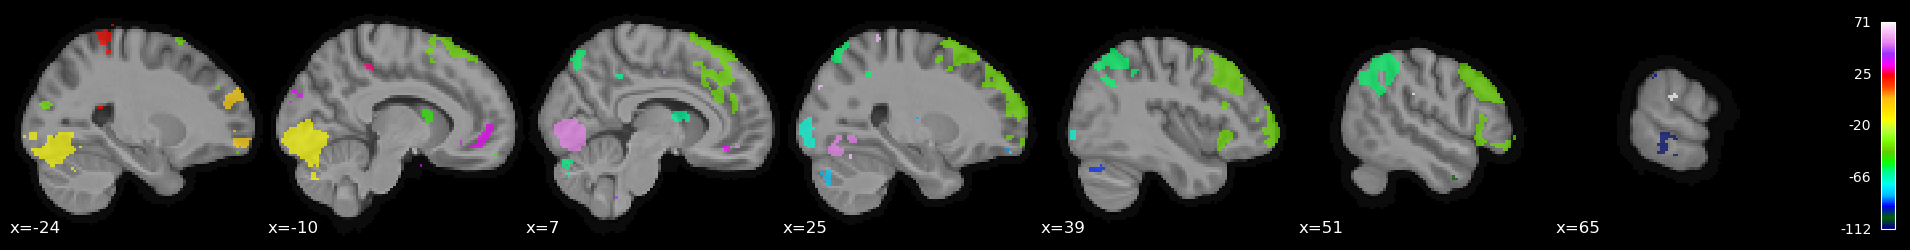

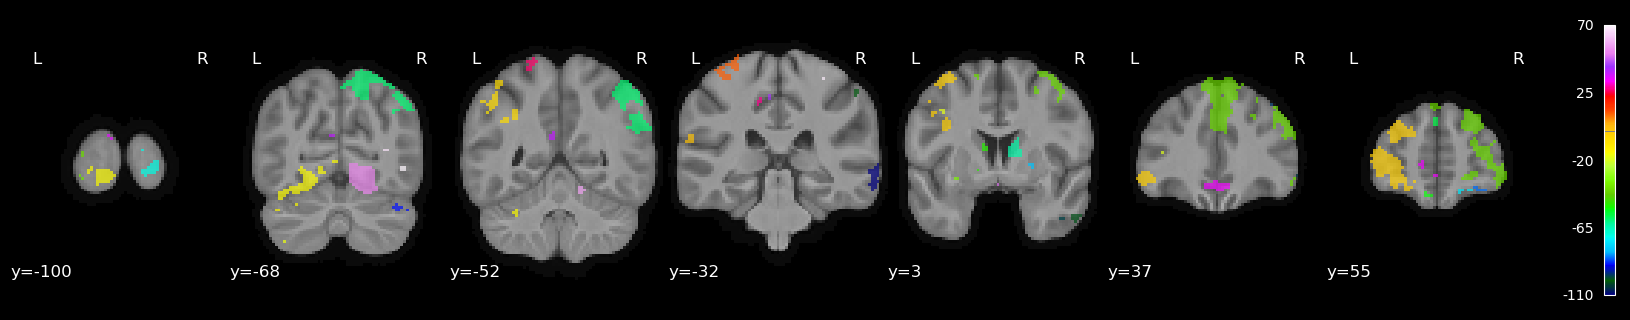

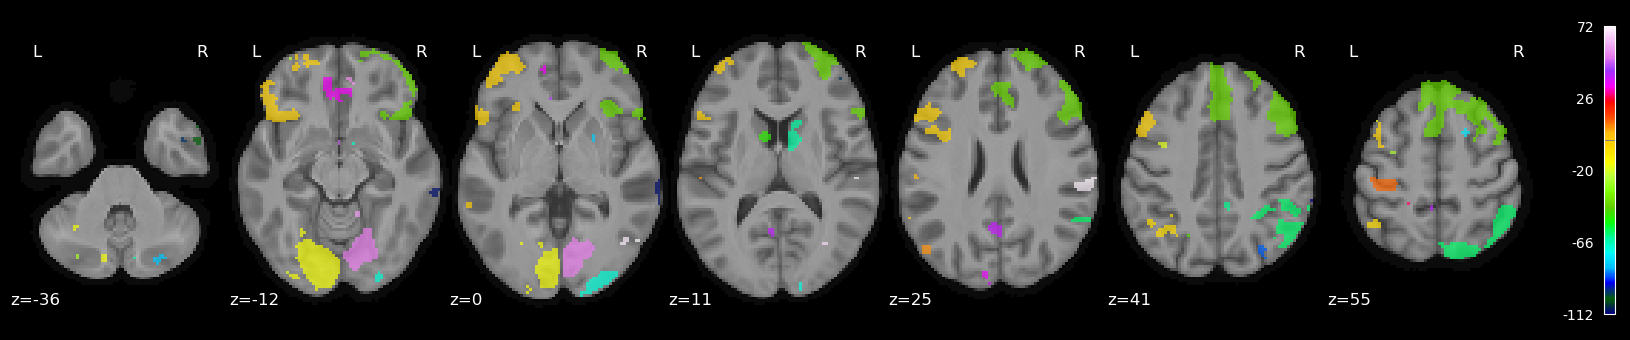

In [9]:
# pull out clusters from a Nilearn 2nd-level Z map (e.g., secondlevel_Value_z.nii.gz)

import os
import numpy as np
import nibabel as nib
from scipy import ndimage
from scipy.stats import norm
from nilearn import plotting

# --- inputs ---
stat_map_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/secondlevel_Value_z.nii.gz"
out_name = "roi_mask_Value_uncorrected_z.nii.gz"

# optional background for plots (must be defined if you plot)
# anat_mean = nib.load("/path/to/sub_average.nii.gz")

# --- load Z map ---
stat_img = nib.load(stat_map_path)
z = stat_img.get_fdata()

# --- choose an uncorrected p threshold and convert to |Z| threshold ---
p_unc = 0.001
two_sided = True
z_thr = norm.isf(p_unc / 2.0) if two_sided else norm.isf(p_unc)

# --- threshold to binary masks (use 1s/0s; don't write the threshold value into the mask) ---
pos_mask = z >= z_thr
neg_mask = z <= -z_thr if two_sided else np.zeros_like(pos_mask, dtype=bool)

# --- label clusters (connectivity defaults to 6-neighbor in 3D; can be changed if you want) ---
pos_labeled, n_pos = ndimage.label(pos_mask.astype(np.uint8))
neg_labeled, n_neg = ndimage.label(neg_mask.astype(np.uint8))

# signed labels: +1..+n_pos for positive clusters; -1..-n_neg for negative clusters
roi_mask_data = pos_labeled + (-neg_labeled)

roi_mask_img = nib.Nifti1Image(roi_mask_data.astype(np.int32), affine=stat_img.affine, header=stat_img.header)

# --- quick QC plots (comment out if you don't have anat_mean) ---
plotting.plot_roi(roi_mask_img, MEAN_ANAT, display_mode="x")
plotting.plot_roi(roi_mask_img, MEAN_ANAT, display_mode="y")
plotting.plot_roi(roi_mask_img, MEAN_ANAT, display_mode="z")

# --- save ---
os.makedirs(OUTPUT_DIR, exist_ok=True)
roi_mask_path = os.path.join(OUTPUT_DIR, 'ROI', out_name)
nib.save(roi_mask_img, roi_mask_path)

print(f"Input Z map: {stat_map_path}")
print(f"Uncorrected p<{p_unc} ({'two-sided' if two_sided else 'one-sided'}) => |Z| >= {z_thr:.3f}")
print(f"Positive clusters: {n_pos} | Negative clusters: {n_neg}")
print(f"ROI mask saved to: {roi_mask_path}")

/tmp/ipykernel_1274833/46585107.py:17: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  roi_mask_dil_image = image.new_img_like(stat_img, roi_mask_dil.astype(int))


Number of clusters is 96


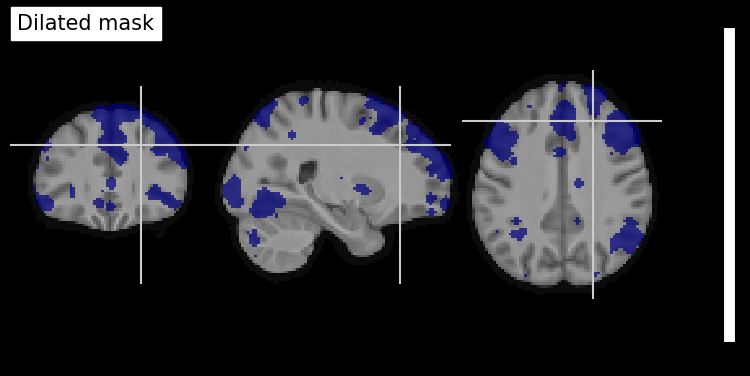

In [10]:
##using clusters about, perform dilation and then save clusters as separate ROI masks

import numpy as np
import os
import nibabel as nib
from nilearn import image, plotting
from scipy import ndimage

# dilation
# a common step to be sure not to forget voxels located on the edge of a ROI. 
# In other words, such operations can fill “holes” in masked voxel representations.

# Binary dilation to ensure no voxels are forgotten
roi_mask_dil = ndimage.binary_dilation(roi_mask_data)

# Visualize the dilated mask
roi_mask_dil_image = image.new_img_like(stat_img, roi_mask_dil.astype(int))
plotting.plot_roi(roi_mask_dil_image, MEAN_ANAT, title='Dilated mask', annotate=False)


# Identification of connected components
labels, n_labels = ndimage.label(roi_mask_dil)
print('Number of clusters is %s' % int(n_labels))

/tmp/ipykernel_1274833/4017536653.py:9: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  roi_img = image.new_img_like(stat_img, roi_data)


Skipped cluster 4, less than threshold
Skipped cluster 8, less than threshold
Skipped cluster 9, less than threshold
Skipped cluster 12, less than threshold
Skipped cluster 13, less than threshold
Skipped cluster 14, less than threshold
Skipped cluster 16, less than threshold
Skipped cluster 17, less than threshold
Skipped cluster 19, less than threshold
Skipped cluster 20, less than threshold
Skipped cluster 21, less than threshold
Skipped cluster 22, less than threshold
Skipped cluster 26, less than threshold
Skipped cluster 28, less than threshold
Skipped cluster 29, less than threshold
Skipped cluster 32, less than threshold
Skipped cluster 33, less than threshold
Skipped cluster 34, less than threshold
Skipped cluster 35, less than threshold
Skipped cluster 36, less than threshold
Skipped cluster 37, less than threshold
Skipped cluster 39, less than threshold
Skipped cluster 43, less than threshold


/home/acr69/.conda/envs/foodvaluation/lib/python3.14/site-packages/nilearn/plotting/displays/_slicers.py:184: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figure = plt.figure(figure, figsize=figsize, facecolor=facecolor)


Skipped cluster 48, less than threshold
Skipped cluster 52, less than threshold
Skipped cluster 54, less than threshold
Skipped cluster 56, less than threshold
Skipped cluster 57, less than threshold
Skipped cluster 61, less than threshold
Skipped cluster 62, less than threshold
Skipped cluster 65, less than threshold
Skipped cluster 68, less than threshold
Skipped cluster 70, less than threshold
Skipped cluster 71, less than threshold
Skipped cluster 72, less than threshold
Skipped cluster 74, less than threshold
Skipped cluster 75, less than threshold
Skipped cluster 78, less than threshold
Skipped cluster 80, less than threshold
Skipped cluster 82, less than threshold
Skipped cluster 83, less than threshold
Skipped cluster 84, less than threshold
Skipped cluster 86, less than threshold
Skipped cluster 87, less than threshold
Skipped cluster 88, less than threshold
Skipped cluster 91, less than threshold
Skipped cluster 93, less than threshold
Skipped cluster 96, less than threshold


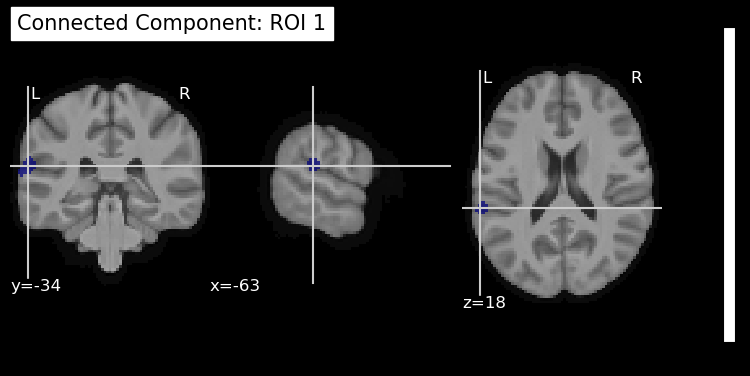

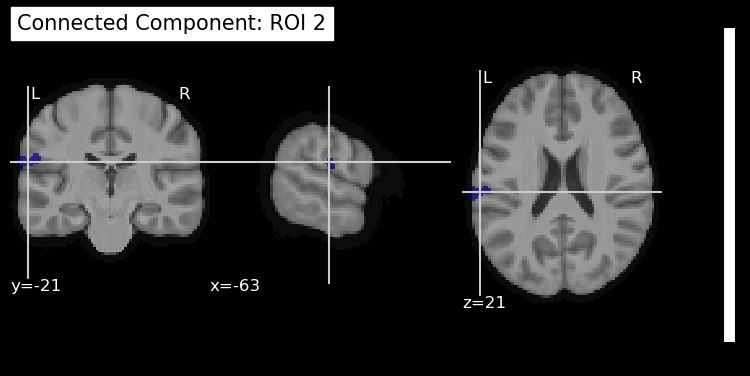

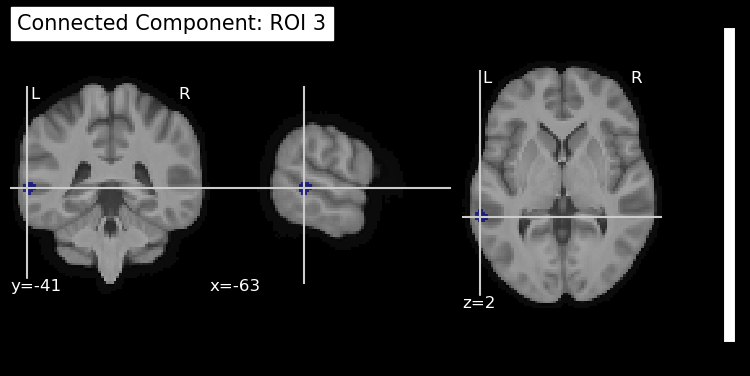

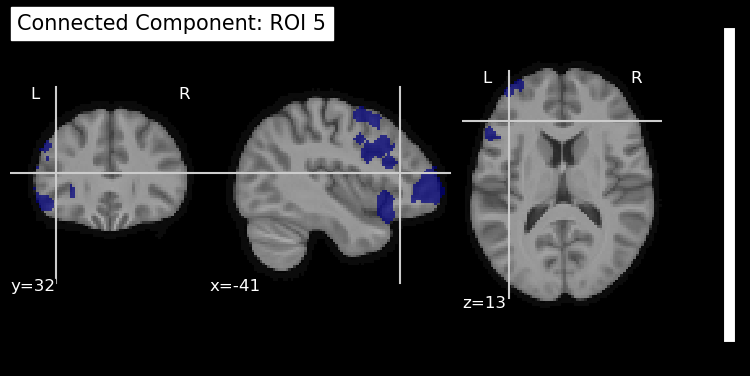

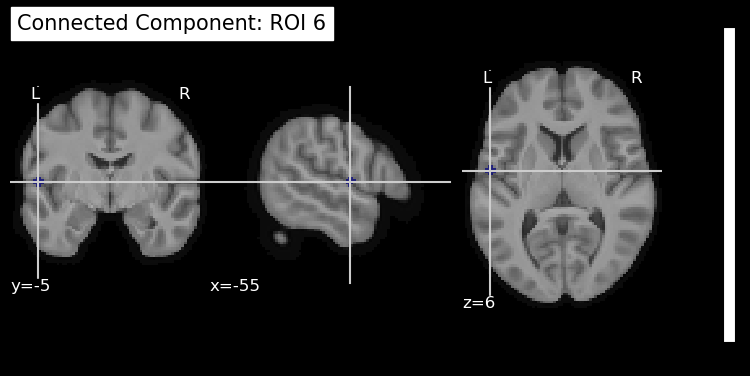

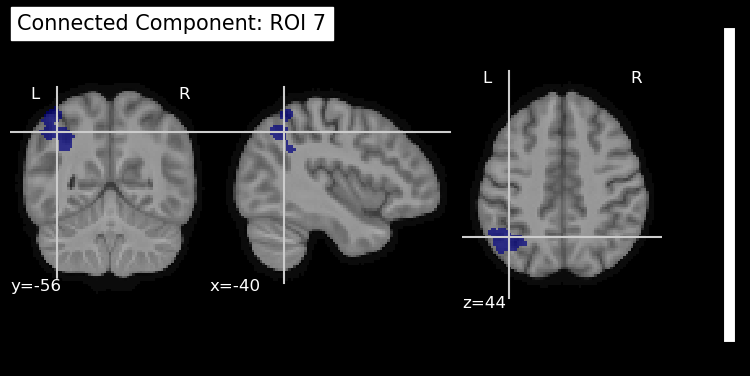

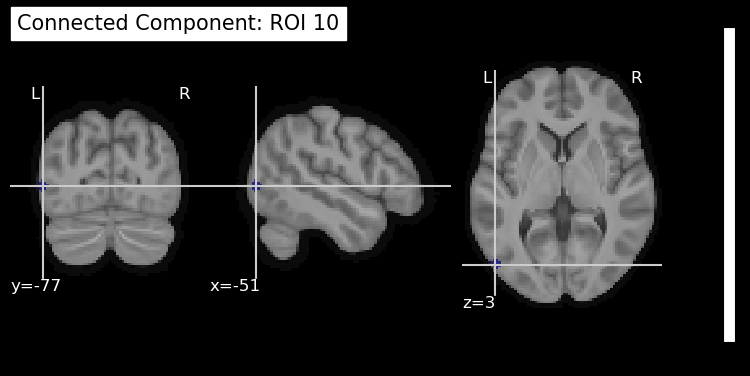

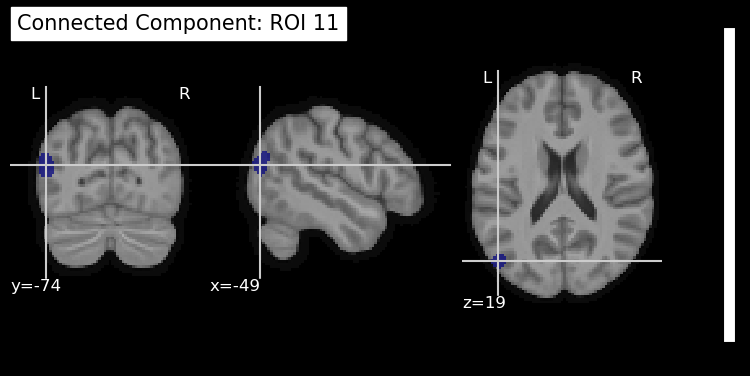

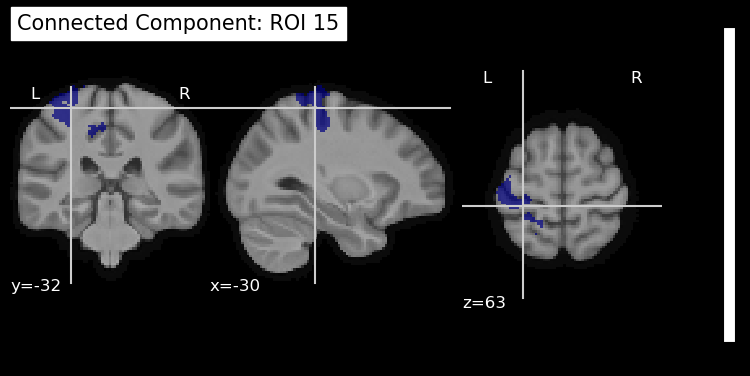

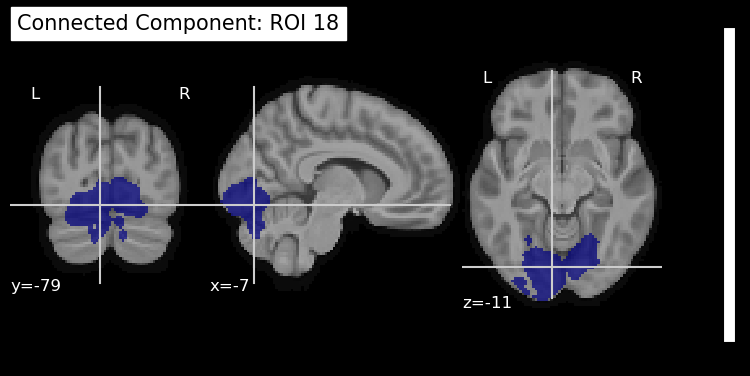

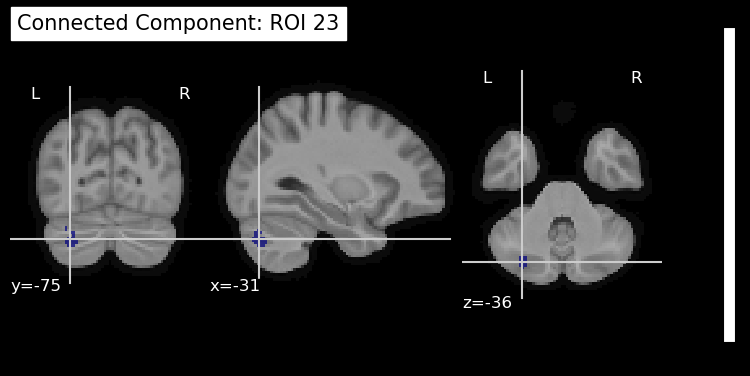

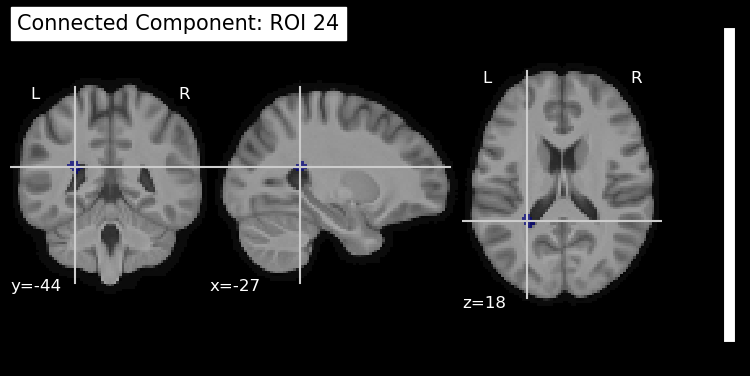

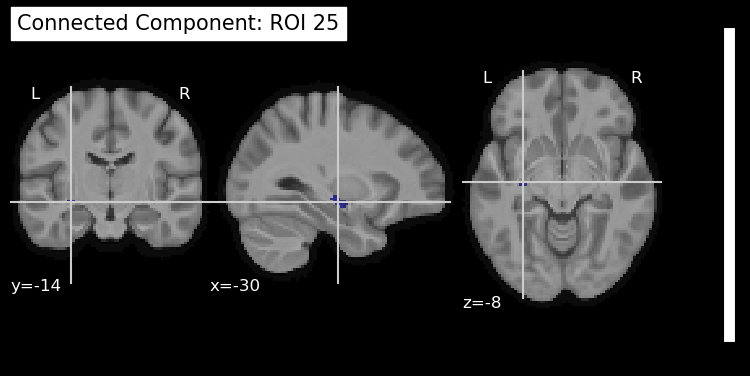

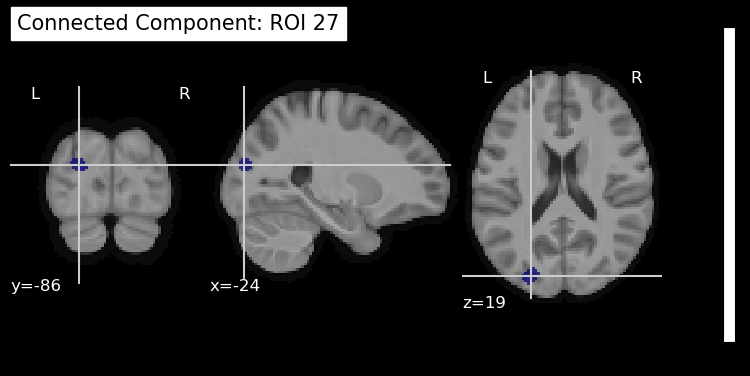

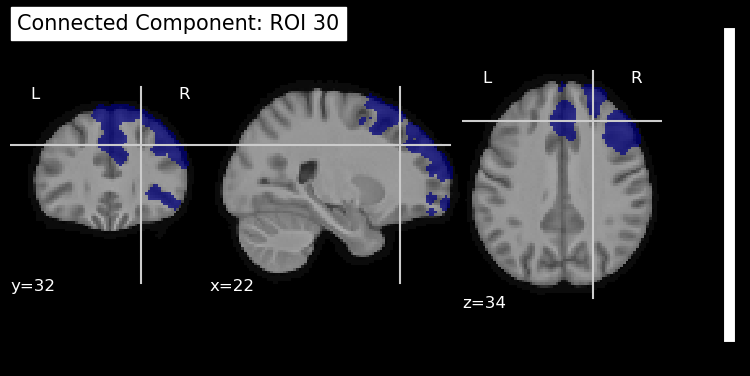

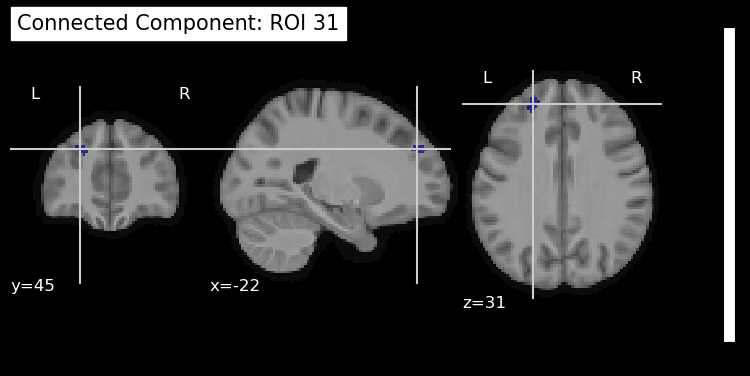

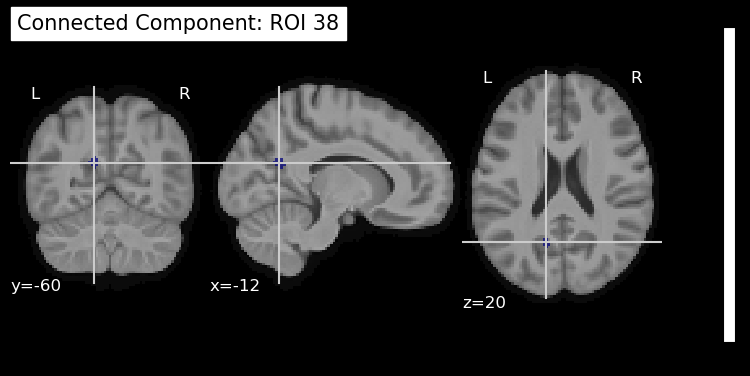

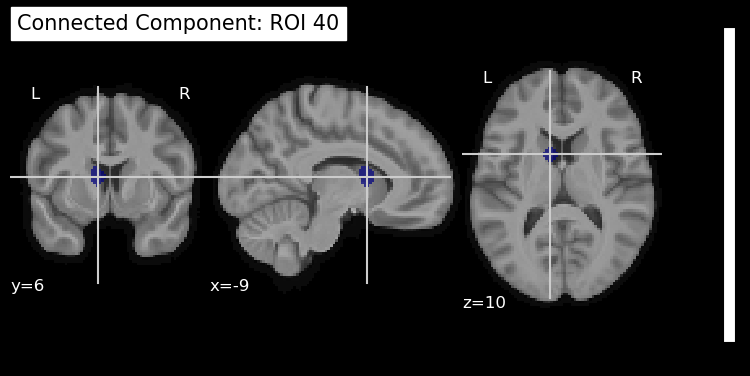

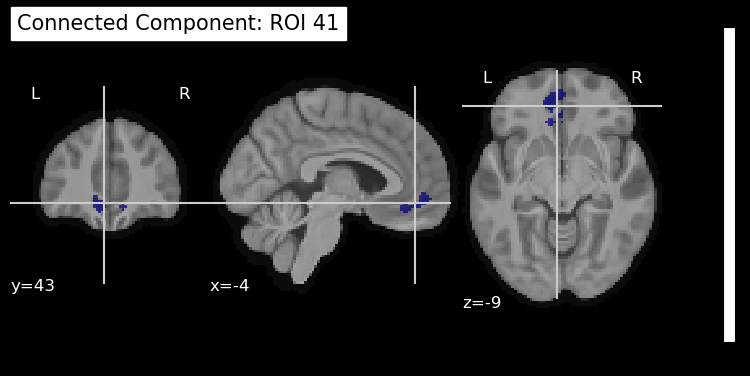

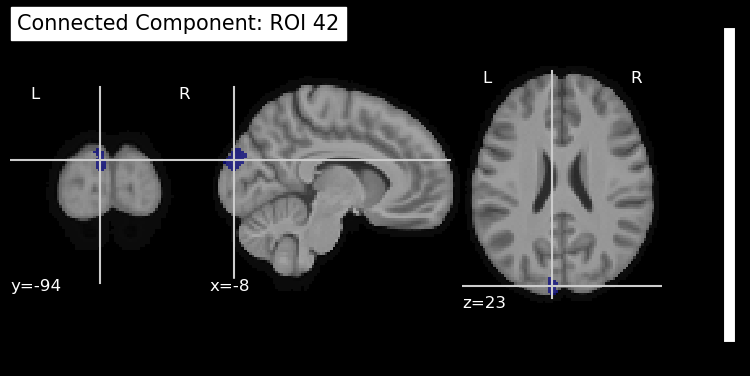

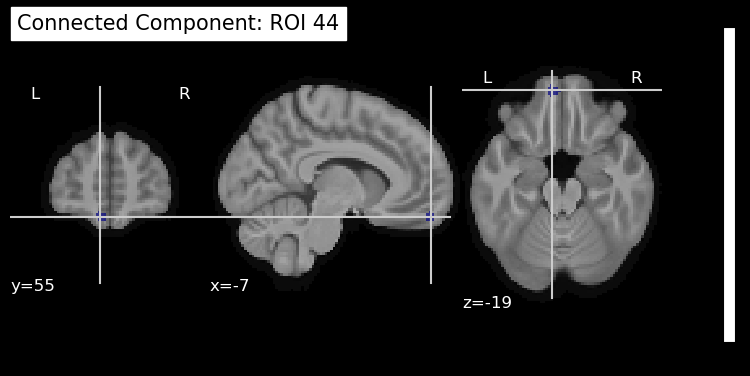

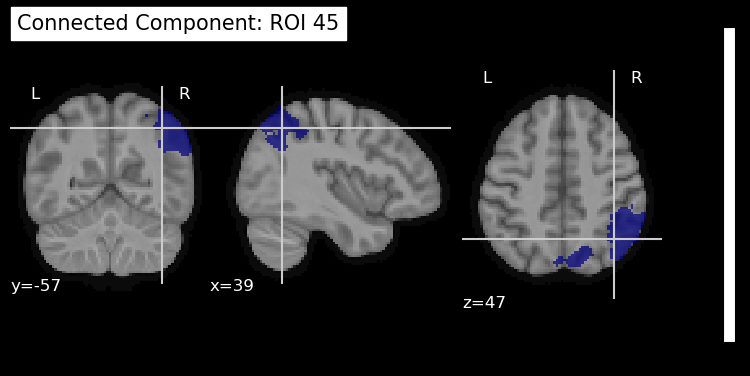

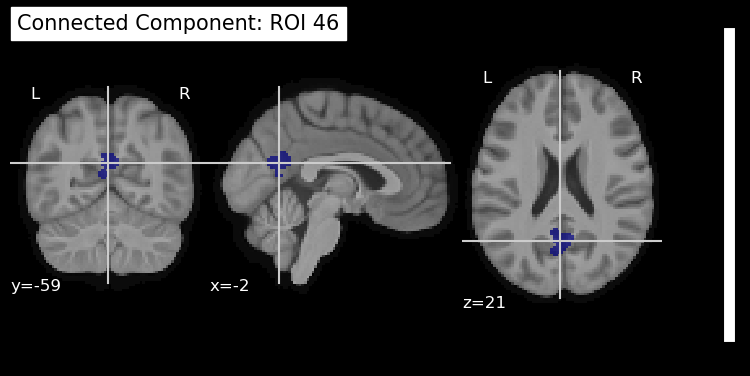

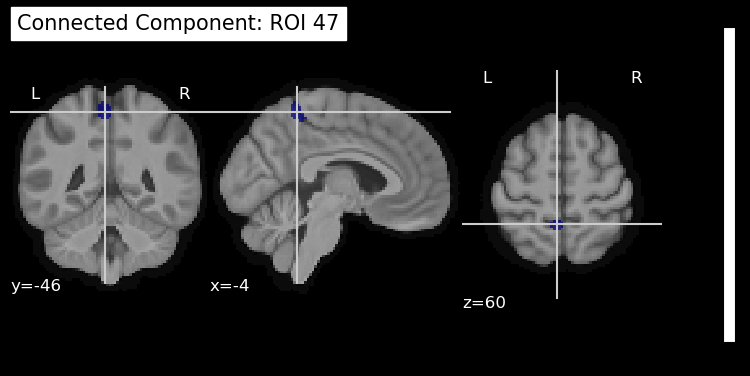

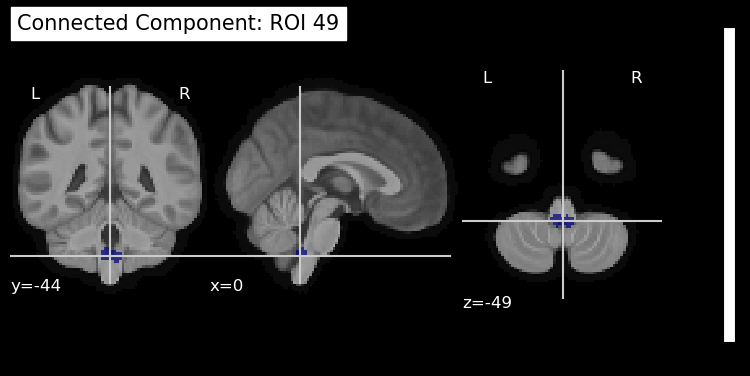

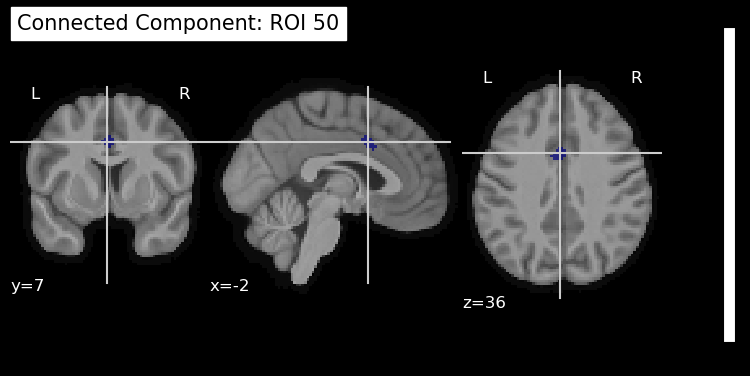

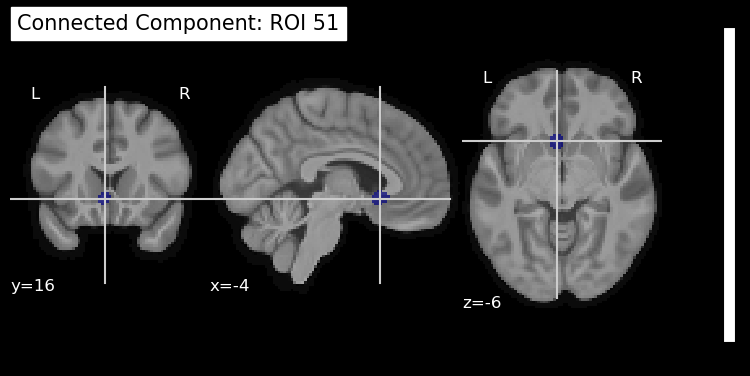

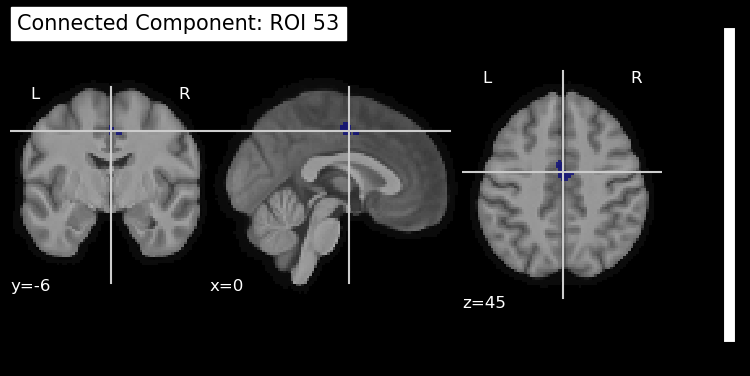

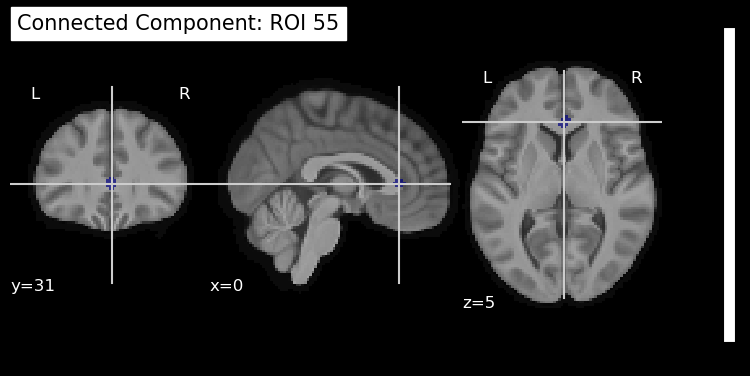

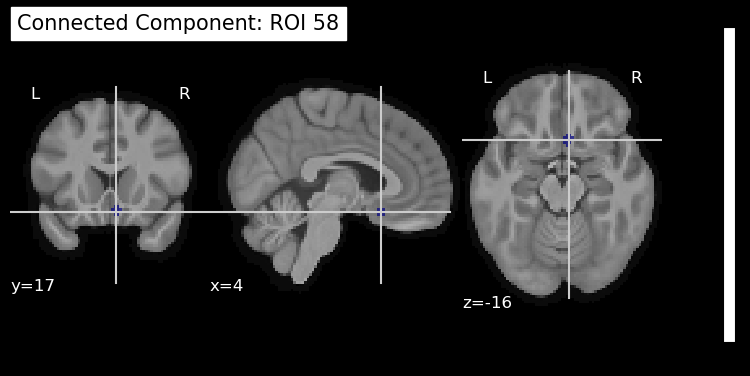

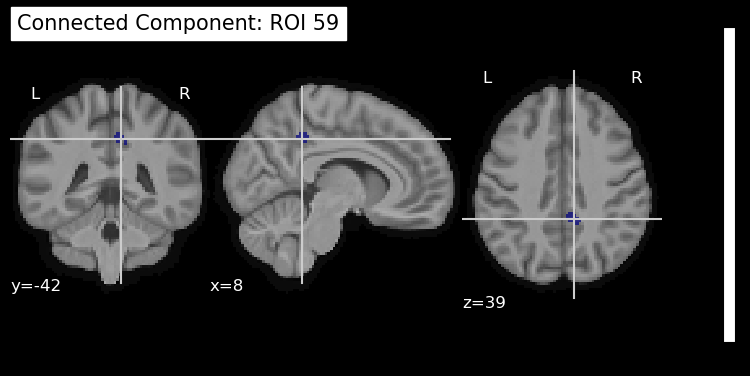

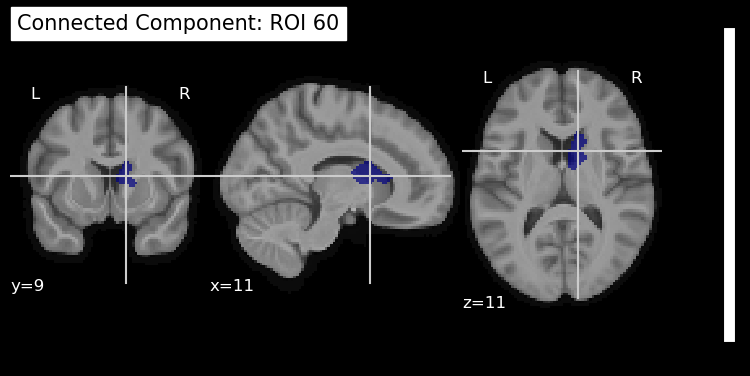

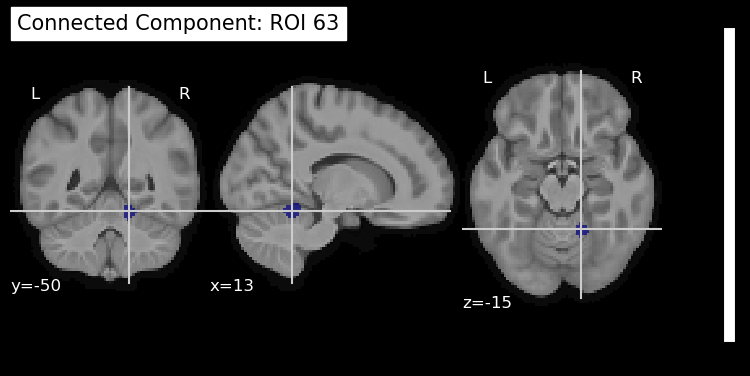

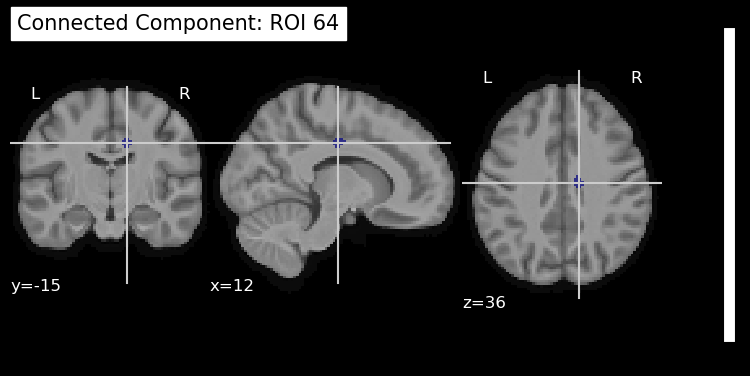

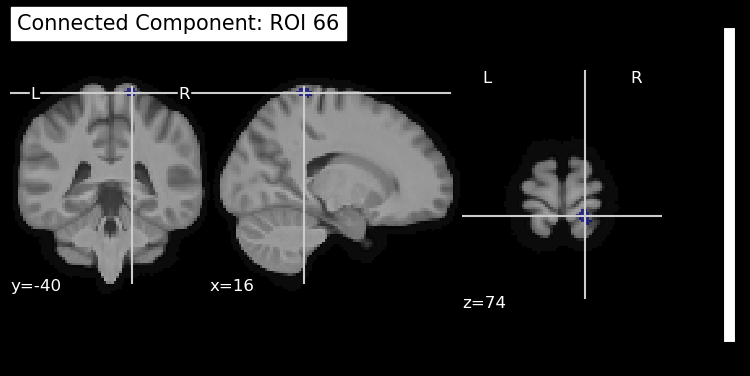

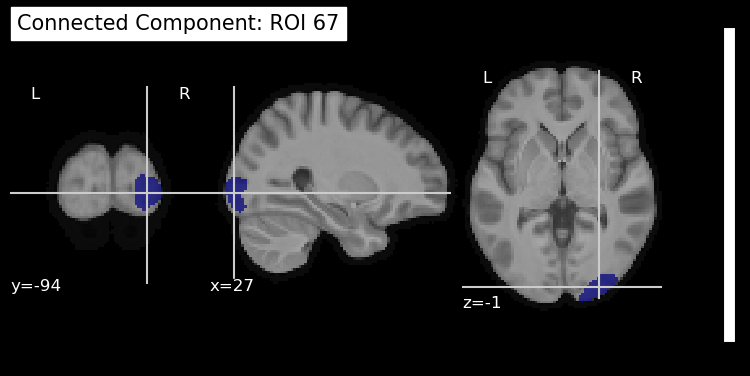

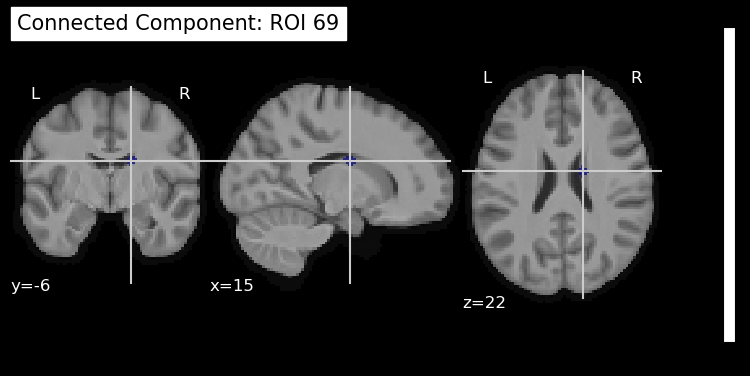

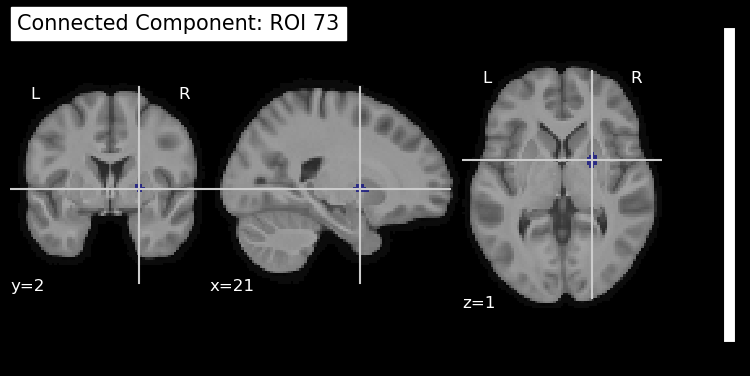

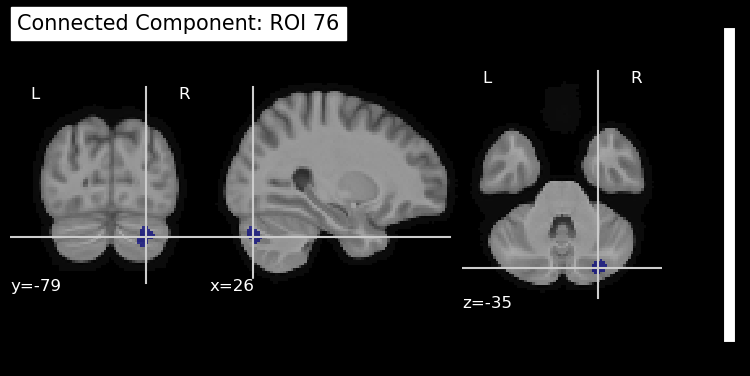

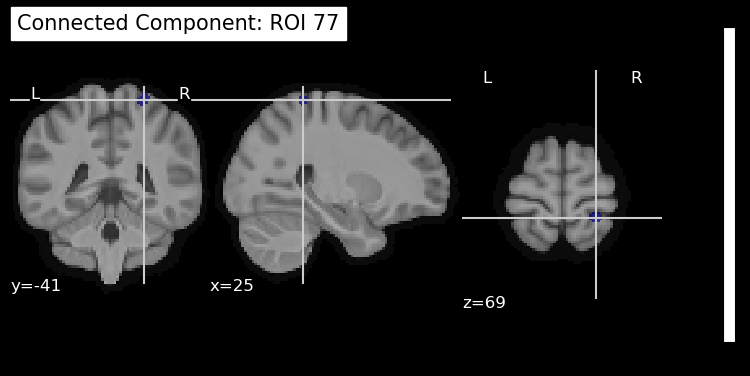

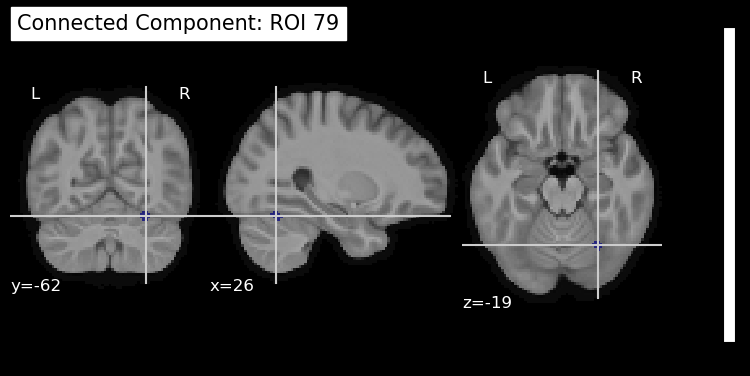

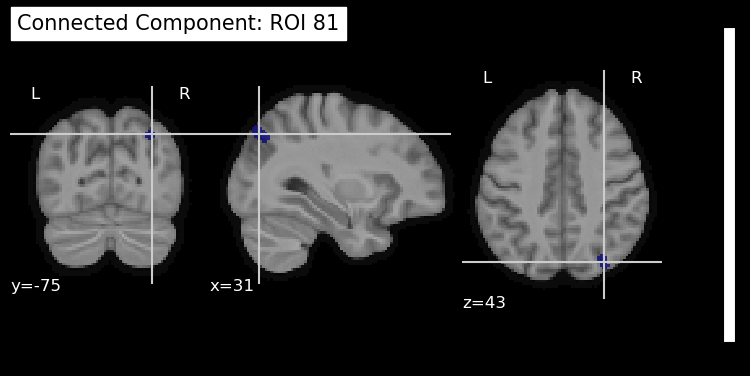

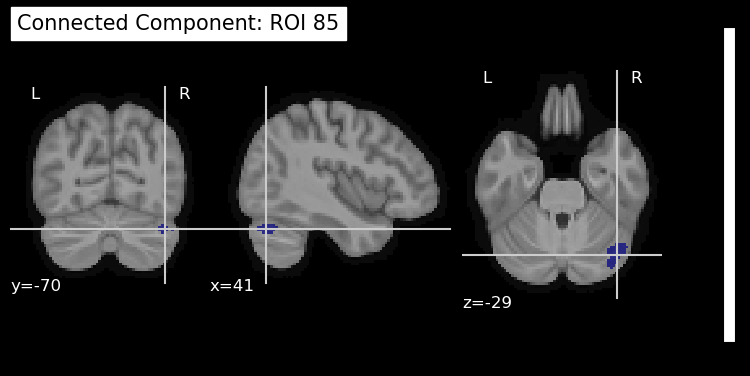

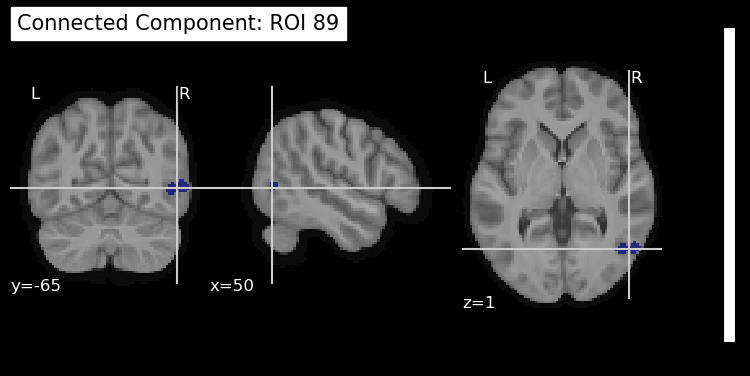

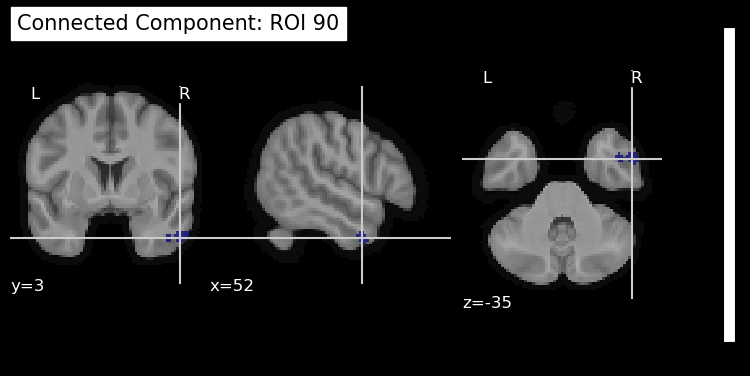

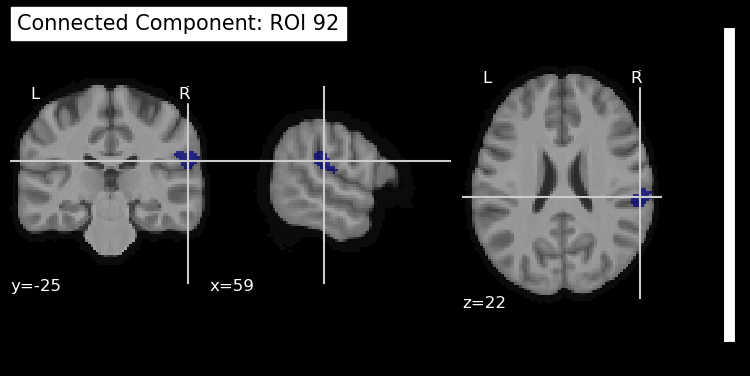

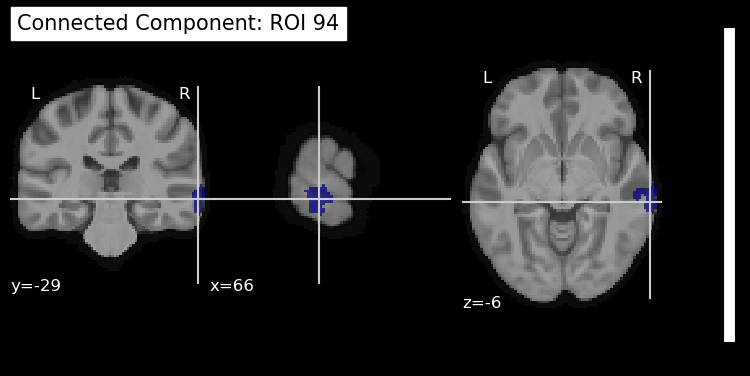

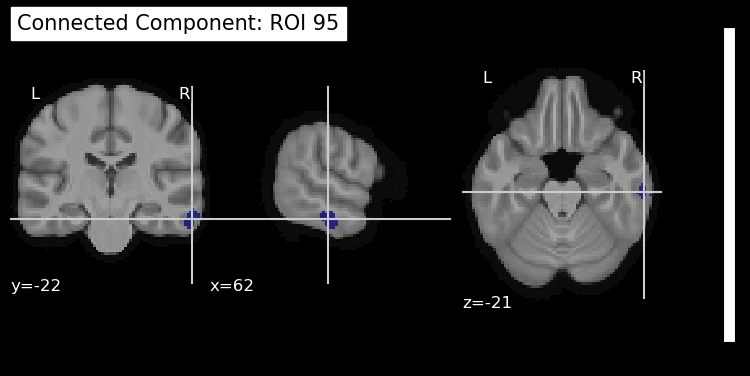

In [11]:
clusters = []
# Save each identified cluster as a separate ROI mask
for i in range(n_labels):
    # Create an individual ROI mask for each cluster
    roi_data = (labels == i + 1).astype(int)
    cluster_size = np.sum(roi_data)

    if cluster_size > 25:
        roi_img = image.new_img_like(stat_img, roi_data)
        
        # Save the ROI mask
        roi_img_path = os.path.join(OUTPUT_DIR, 'ROI', f'roi_{i+1}_uncorrected.nii.gz')
        roi_img.to_filename(roi_img_path)
        
        # Visualize the ROI mask
        plotting.plot_roi(roi_img, MEAN_ANAT, title=f'Connected Component: ROI {i+1}')
        
        clusters.append(roi_img)
    else:
        print(f'Skipped cluster {i+1}, less than threshold')

print("ROI masks for individual clusters saved and visualized.")

## Concetate into 4D image

In [12]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn.image import load_img, concat_imgs
from nilearn import plotting

# -----------------------------
# Build a 4D image by concatenating 1st-level "Value" contrast maps (one per subject)
# so you can extract ROI means per subject with your NiftiMasker code.
# -----------------------------

# Set these to match your filenames
firstlevel_dir = Path(OUTPUT_DIR)
contrast_name = "Value"                                      
# Example expected file per subject:
#   <firstlevel_dir>/<sub>/<sub>_Value_con.nii.gz
# or adjust pattern below to match your pipeline.

def collect_firstlevel_contrasts(firstlevel_dir: Path, subjects: list, contrast: str):
    paths = []
    missing = []
    for sub in subjects:
        p = firstlevel_dir / sub / f"{sub}_{contrast}_effect.nii.gz"
        if p.exists():
            paths.append(str(p))
        else:
            missing.append(str(p))
    return paths, missing

# Collect subject maps
con_paths, missing = collect_firstlevel_contrasts(firstlevel_dir, SUBJECTS, contrast_name)

print(f"Found {len(con_paths)} subject maps for {contrast_name}")
if missing:
    print("Missing (showing up to 10):")
    for m in missing[:10]:
        print("  ", m)

if len(con_paths) == 0:
    raise RuntimeError("No first-level contrast maps found; fix firstlevel_dir/pattern/contrast_name.")

# Concatenate into a single 4D image: (X, Y, Z, Nsubjects)
con_imgs_4d = concat_imgs(con_paths)

# Save the 4D image for downstream ROI extraction/plotting
out_4d_path = Path(OUTPUT_DIR) / f"none_glm_{contrast_name}_all_sub_4d.nii.gz"
out_4d_path.parent.mkdir(parents=True, exist_ok=True)
con_imgs_4d.to_filename(str(out_4d_path))
print(f"Saved 4D concatenated image to: {out_4d_path}")


# Now point your extraction code at:
functional_img_path = str(out_4d_path)
print("Use this as functional_img_path:", functional_img_path)

Found 50 subject maps for Value
Saved 4D concatenated image to: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/none_glm_Value_all_sub_4d.nii.gz
Use this as functional_img_path: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/none_glm_Value_all_sub_4d.nii.gz


## Back to ROI!

/tmp/ipykernel_2960238/1365341211.py:16: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import input_data, plotting


ROI label: roi41_x-4_y43_z-9
ROI mask: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/roi_41_uncorrected.nii.gz
Functional: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/none_glm_Value_all_sub_4d.nii.gz
ROI voxels: 463
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41_x-4_y43_z-9_ROIMaskOverlay.jpeg


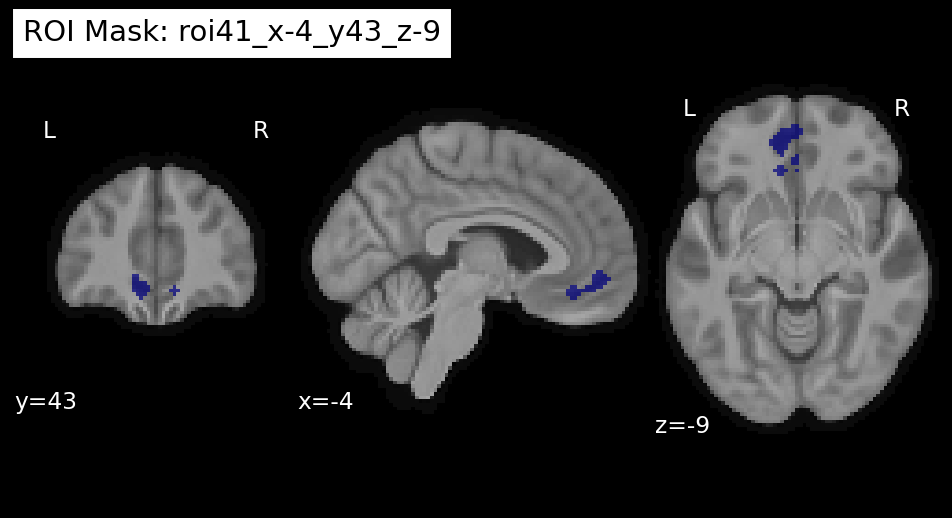


One-sample ROI test (Value contrast)
Contrast (key): Value
Contrast (label): Value
ROI: roi41_x-4_y43_z-9
N subjects: 50
Mean ROI signal: 0.056209 (SD=0.073846, SEM=0.010443)
t(49) = 5.382, p = 2.06e-06
Cohen's d = 0.761
95% CI for mean: [0.035222, 0.077196]


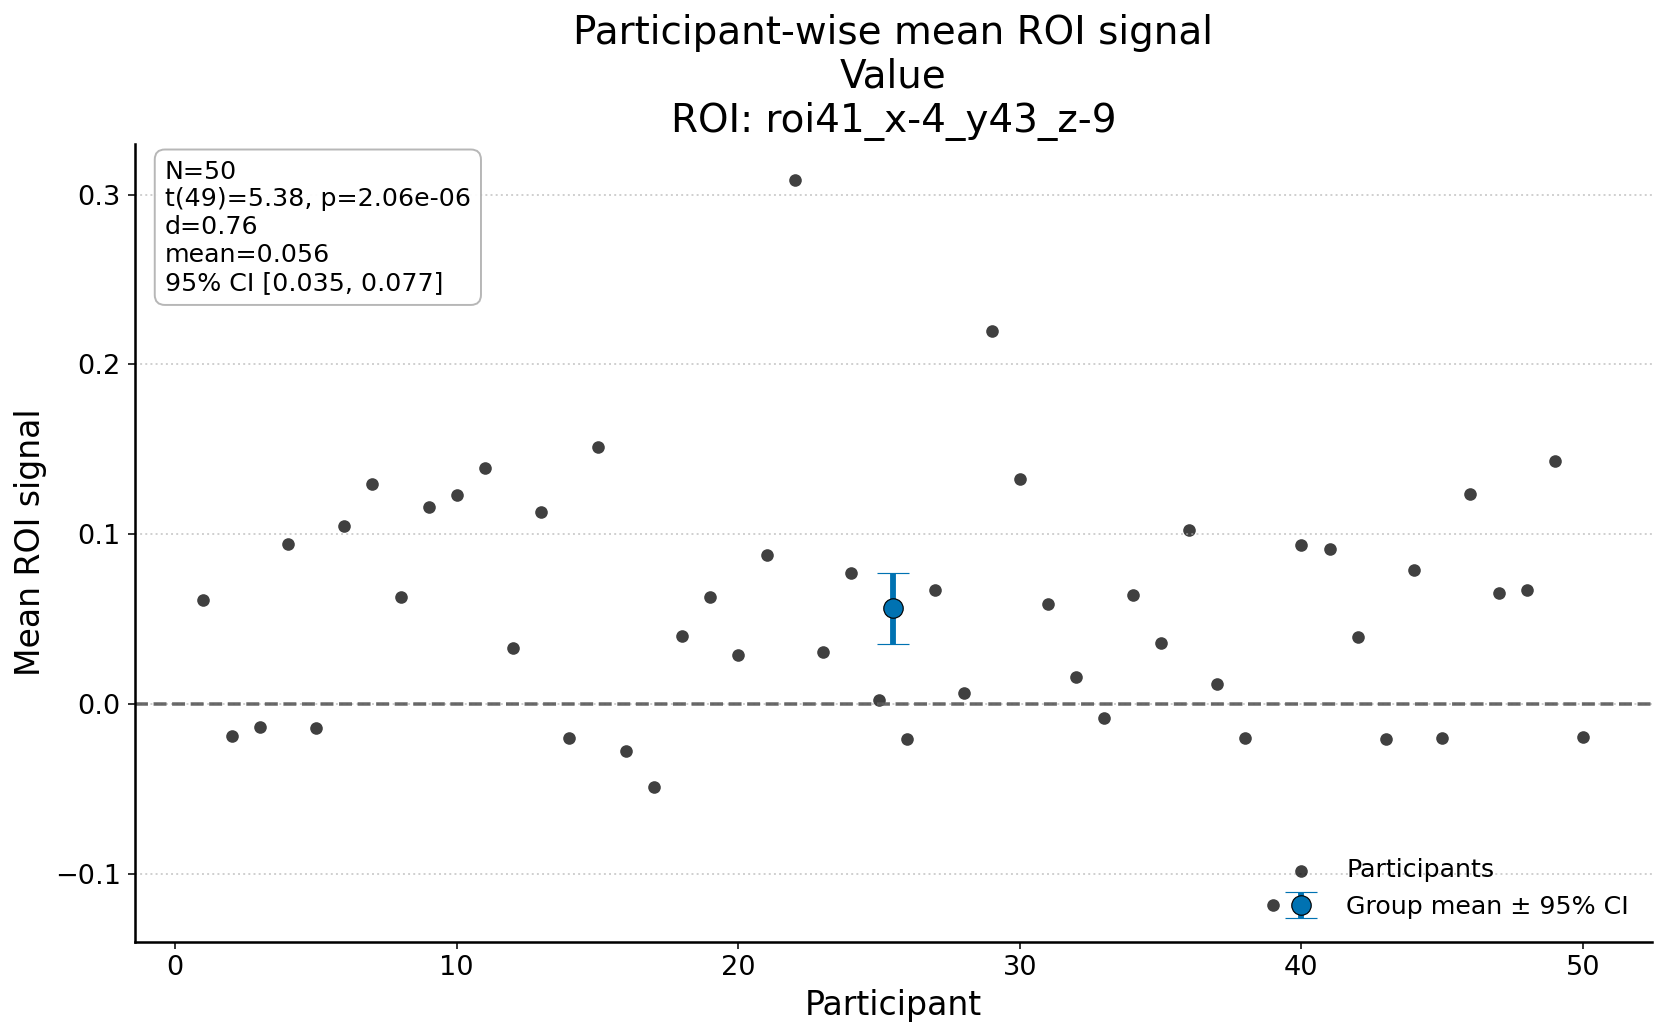

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41_x-4_y43_z-9_Value_ParticipantScatter_MeanCI.jpeg


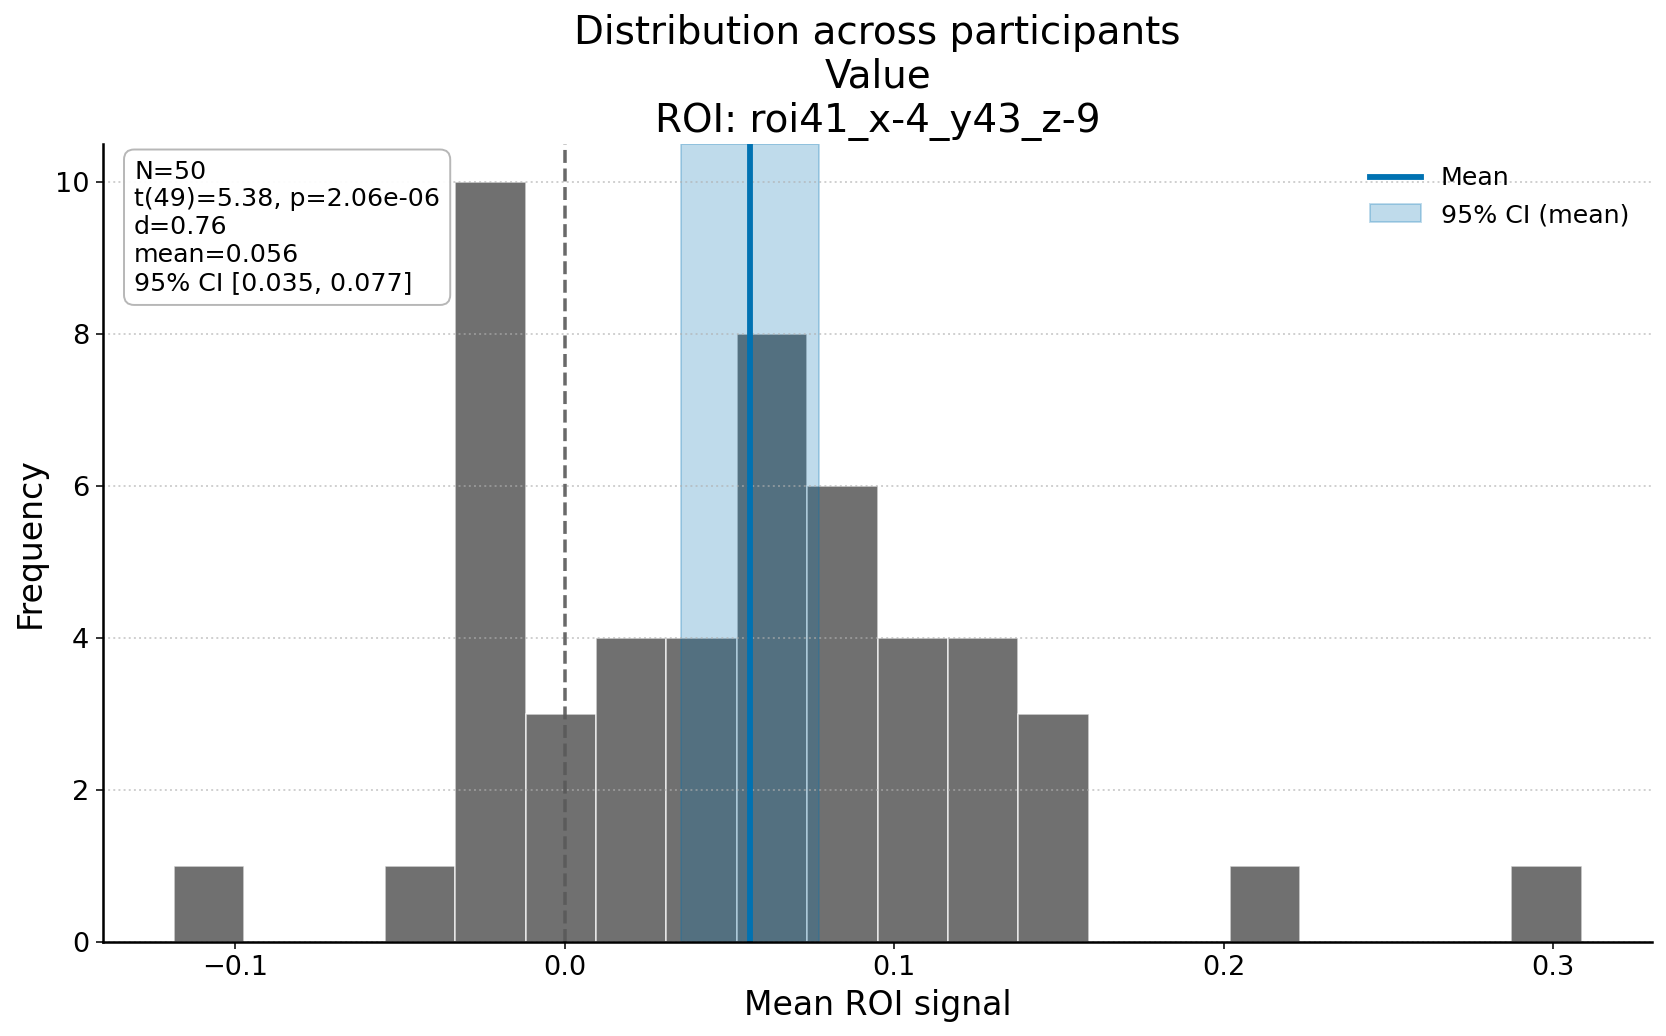

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41_x-4_y43_z-9_Value_Histogram_MeanCI.jpeg


In [8]:
# ROI41 (unsmoothed/uncorrected mask) — formatted/saved like your other ROI scripts
# - Uses existing ROI mask: roi_41_uncorrected.nii.gz
# - Extracts participant-wise mean ROI signal from 4D Value image
# - One-sample t-test vs 0 with 95% CI + Cohen's d
# - Saves 3 figures: ROI overlay + participant scatter (mean ± 95% CI) + histogram (mean ± 95% CI)
#
# Output dir:
# /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures
#
# Filenames use ROI label "roi41" (no sphere)

import os
import re
import numpy as np
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers: stats + CI + effect size + filenames
# -----------------------
def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

# -----------------------
# Figure styling (match your other scripts)
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.3,
})

MEAN_COLOR = "#0072B2"
ZERO_COLOR = "0.35"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value"
functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_all_sub_4d.nii.gz")
roi_mask_path = os.path.join(str(OUTPUT_DIR), "ROI", "roi_41_uncorrected.nii.gz")

anat_img = load_img(str(MEAN_ANAT))  # background for overlay

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

# Put your ROI center coords here (MNI mm); adjust if different for this mask
coords = (-4, 43, -9)
roi_label = f"roi41_x{coords[0]}_y{coords[1]}_z{coords[2]}"
roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# Output folder
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load images
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

n_vox = int(np.sum(roi_mask_img.get_fdata() > 0))
print(f"ROI label: {roi_label}")
print(f"ROI mask: {roi_mask_path}")
print(f"Functional: {functional_img_path}")
print(f"ROI voxels: {n_vox}")

# -----------------------
# Figure 1: ROI overlay (SAVE; no colorbar)
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask: {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)

roi_plot_title = "ROIMaskOverlay"
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_{roi_plot_title}.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# optional inline
disp_inline = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask: {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)
plt.show()

# -----------------------
# Extract mean ROI signal per subject
# -----------------------
masker = input_data.NiftiMasker(mask_img=roi_mask_img, standardize=False)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
x = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)
x = x[~np.isnan(x)]

n = int(x.size)
df = n - 1

# -----------------------
# Stats: one-sample vs 0 with 95% CI + Cohen's d
# -----------------------
group_mean = float(np.mean(x))
group_sd = float(np.std(x, ddof=1))
group_sem = float(stats.sem(x))

t_statistic, p_value = stats.ttest_1samp(x, 0.0, nan_policy="omit")
t_statistic = float(t_statistic)
p_value = float(p_value)

d = cohens_d_onesample(x, mu0=0.0)
_, (ci_lo, ci_hi) = mean_ci_t(x, confidence=0.95)

print("\nOne-sample ROI test (Value contrast)")
print(f"Contrast (key): {contrast_key}")
print(f"Contrast (label): {contrast_label}")
print(f"ROI: {roi_label}")
print(f"N subjects: {n}")
print(f"Mean ROI signal: {group_mean:.6f} (SD={group_sd:.6f}, SEM={group_sem:.6f})")
print(f"t({df}) = {t_statistic:.3f}, p = {p_value:.4g}")
print(f"Cohen's d = {d:.3f}")
print(f"95% CI for mean: [{ci_lo:.6f}, {ci_hi:.6f}]")

stats_text = (
    f"N={n}\n"
    f"t({df})={t_statistic:.2f}, p={p_value:.3g}\n"
    f"d={d:.2f}\n"
    f"mean={group_mean:.3f}\n"
    f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]"
)

# -----------------------
# Figure 2: participant scatter + mean ± 95% CI (SAVE)
# -----------------------
fig1, ax1 = plt.subplots(figsize=(12, 7.5))
x_subjects = np.arange(1, n + 1)

ax1.scatter(
    x_subjects, x,
    color="black", alpha=0.75, s=42, linewidths=0,
    label="Participants"
)

ax1.errorbar(
    x=float(np.mean(x_subjects)),
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.0,
    capsize=8,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.6,
    label="Group mean ± 95% CI"
)

ax1.axhline(y=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
ax1.set_xlabel("Participant")
ax1.set_ylabel("Mean ROI signal")

plot1_title = "ParticipantScatter_MeanCI"
ax1.set_title(f"Participant-wise mean ROI signal\n{contrast_label}\nROI: {roi_label}")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax1.text(
    0.02, 0.98, stats_text,
    transform=ax1.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax1.legend(frameon=False, loc="lower right")
plt.tight_layout()

fname1 = f"{roi_slug}_{contrast_slug}_{plot1_title}.jpeg"
out1 = os.path.join(FIG_DIR, fname1)
fig1.savefig(out1, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out1}")

# -----------------------
# Figure 3: histogram + mean and 95% CI (SAVE)
# -----------------------
fig2, ax2 = plt.subplots(figsize=(12, 7.5))

ax2.hist(x, bins=20, color="0.25", alpha=0.75, edgecolor="white", linewidth=0.8)
ax2.axvline(x=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)

ax2.axvline(group_mean, color=MEAN_COLOR, linewidth=3.0, label="Mean")
ax2.axvspan(ci_lo, ci_hi, color=MEAN_COLOR, alpha=0.25, label="95% CI (mean)")

ax2.set_xlabel("Mean ROI signal")
ax2.set_ylabel("Frequency")

plot2_title = "Histogram_MeanCI"
ax2.set_title(f"Distribution across participants\n{contrast_label}\nROI: {roi_label}")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax2.text(
    0.02, 0.98, stats_text,
    transform=ax2.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax2.legend(frameon=False, loc="upper right")
plt.tight_layout()

fname2 = f"{roi_slug}_{contrast_slug}_{plot2_title}.jpeg"
out2 = os.path.join(FIG_DIR, fname2)
fig2.savefig(out2, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out2}")

MNI [-4, 43, -9]
ROI mask: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/roi_41_uncorrected.nii.gz
Functional: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/none_glm_Value_all_sub_4d.nii.gz
ROI voxels: 463


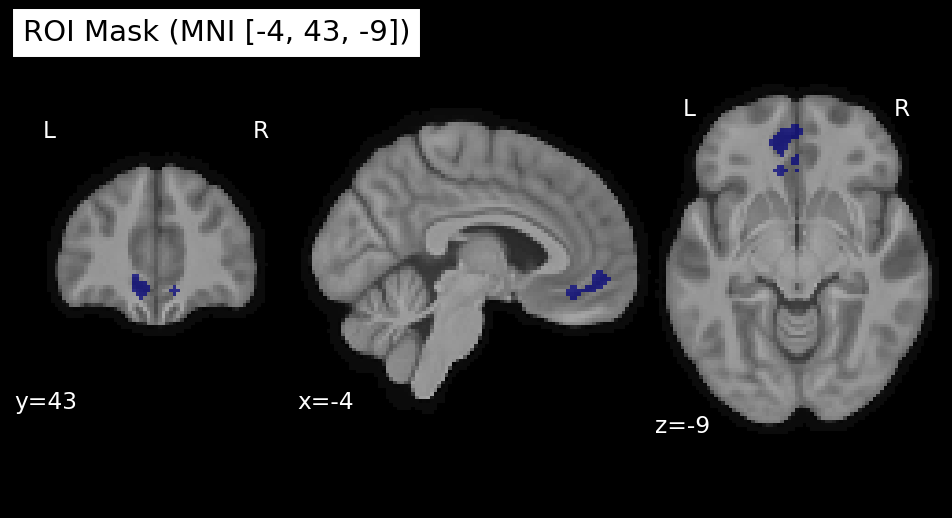

[OK] Saved ROI overlay: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41_ROIMaskOverlay.jpeg

One-sample ROI test (Value contrast)
Contrast (key): Value
Contrast (label): Value
MNI [-4, 43, -9]
N subjects: 50
Mean ROI signal: 0.056209 (SD=0.073846, SEM=0.010443)
t(49) = 5.382, p = 2.06e-06
Cohen's d = 0.761
95% CI for mean: [0.035222, 0.077196]


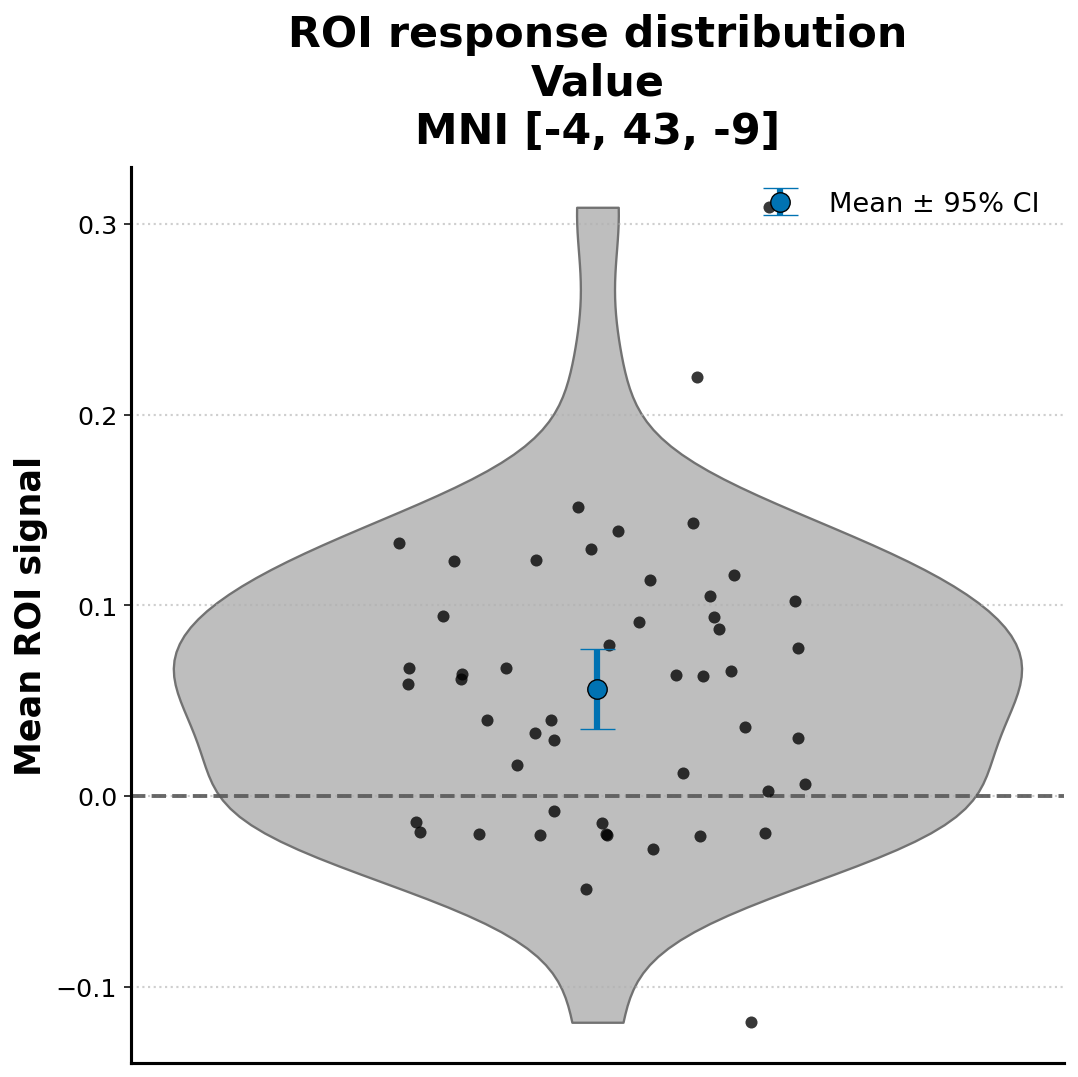

[OK] Saved violin: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41_Value_ViolinPoints_MeanCI.jpeg


In [11]:
import os
import re
import numpy as np
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt

from nilearn import plotting
from nilearn.maskers import NiftiMasker
from nilearn.image import load_img
from scipy import stats


# ============================================================
# Helpers
# ============================================================
def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan


# ============================================================
# Style (bigger/bolder, easier to read)
# ============================================================
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "axes.linewidth": 1.6,
})

MEAN_COLOR = "#0072B2"
ZERO_COLOR = "0.35"
VIOLIN_COLOR = "#BEBEBE"


# ============================================================
# Inputs (ROI41 rank-regression)
# Assumes OUTPUT_DIR and MEAN_ANAT exist in your environment.
# ============================================================
contrast_key = "Value"
functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_all_sub_4d.nii.gz")
roi_mask_path = os.path.join(str(OUTPUT_DIR), "ROI", "roi_41_uncorrected.nii.gz")

anat_img = load_img(str(MEAN_ANAT))  # background for overlay

try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key
contrast_slug = safe_filename(contrast_label)

# ROI label for plots (requested exact format)
coords = (-4, 43, -9)
roi_label_plot = f"MNI [{coords[0]}, {coords[1]}, {coords[2]}]"

# Keep filenames simple (as requested: "roi41", no sphere)
roi_slug = safe_filename("roi41")

# Output folder
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures"
os.makedirs(FIG_DIR, exist_ok=True)


# ============================================================
# Load images
# ============================================================
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

n_vox = int(np.sum(roi_mask_img.get_fdata() > 0))
print(f"{roi_label_plot}")
print(f"ROI mask: {roi_mask_path}")
print(f"Functional: {functional_img_path}")
print(f"ROI voxels: {n_vox}")


# ============================================================
# 1) ROI overlay: show in output + save (ortho)
# ============================================================
roi_display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask ({roi_label_plot})",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)

# Show in notebook output
plotting.show()

# Save
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
roi_display.savefig(roi_out, dpi=600)
roi_display.close()
print(f"[OK] Saved ROI overlay: {roi_out}")


# ============================================================
# Extract mean ROI signal per subject (Value contrast)
# ============================================================
masker = NiftiMasker(mask_img=roi_mask_img, standardize=False)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
x = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)
x = x[~np.isnan(x)]

n = int(x.size)
df = n - 1


# ============================================================
# Stats: one-sample vs 0 with 95% CI + Cohen's d
# ============================================================
group_mean = float(np.mean(x))
group_sd = float(np.std(x, ddof=1))
group_sem = float(stats.sem(x))

t_statistic, p_value = stats.ttest_1samp(x, 0.0, nan_policy="omit")
t_statistic = float(t_statistic)
p_value = float(p_value)

d = cohens_d_onesample(x, mu0=0.0)
_, (ci_lo, ci_hi) = mean_ci_t(x, confidence=0.95)

print("\nOne-sample ROI test (Value contrast)")
print(f"Contrast (key): {contrast_key}")
print(f"Contrast (label): {contrast_label}")
print(f"{roi_label_plot}")
print(f"N subjects: {n}")
print(f"Mean ROI signal: {group_mean:.6f} (SD={group_sd:.6f}, SEM={group_sem:.6f})")
print(f"t({df}) = {t_statistic:.3f}, p = {p_value:.4g}")
print(f"Cohen's d = {d:.3f}")
print(f"95% CI for mean: [{ci_lo:.6f}, {ci_hi:.6f}]")


# ============================================================
# 2) Violin + subject points + mean ± 95% CI (save)
# ============================================================
figV, axV = plt.subplots(figsize=(7.8, 7.8))

sns.violinplot(
    y=x,
    ax=axV,
    color=VIOLIN_COLOR,
    inner=None,
    cut=0,
    linewidth=1.2
)

sns.stripplot(
    y=x,
    ax=axV,
    color="black",
    alpha=0.78,
    jitter=0.20,
    size=6.2,
    zorder=4
)

axV.errorbar(
    x=0,
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.2,
    capsize=9,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.7,
    zorder=5,
    label="Mean ± 95% CI"
)

axV.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=2.0, alpha=0.9)
axV.set_xticks([])
axV.set_xlabel("")
axV.set_ylabel("Mean ROI signal")
axV.set_title(f"ROI response distribution\n{contrast_label}\n{roi_label_plot}", pad=12)

axV.spines["top"].set_visible(False)
axV.spines["right"].set_visible(False)
axV.grid(True, axis="y", linestyle=":", linewidth=1.1, alpha=0.6)
axV.legend(frameon=False, loc="upper right")

plt.tight_layout()
violin_out = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_ViolinPoints_MeanCI.jpeg")
figV.savefig(violin_out, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved violin: {violin_out}")

## Neurosynth overlap

Loading images...
  ROI   shape : (97, 115, 97)  | voxel size: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
  Atlas shape : (91, 109, 91) | voxel size: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Shapes / affines differ — resampling ROI to atlas space.
  Resampling ROI to atlas space...

ROI–Atlas Overlap Report
ROI file   : /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/roi_41_uncorrected.nii.gz
Atlas file : /nfs/roberts/pi/pi_il77/shared/Neurosynth Parcellation_0.nii.gz
Total ROI voxels       : 463
Overlapping ROI voxels : 463

File value   Region name                                  Voxels   % of ROI
---------------------------------------------------------------------------
33           vmPFC                                           446     96.33%
3            DMPFC                                            17      3.67%

Report saved → /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/roi_41_atlas_overlap_report.

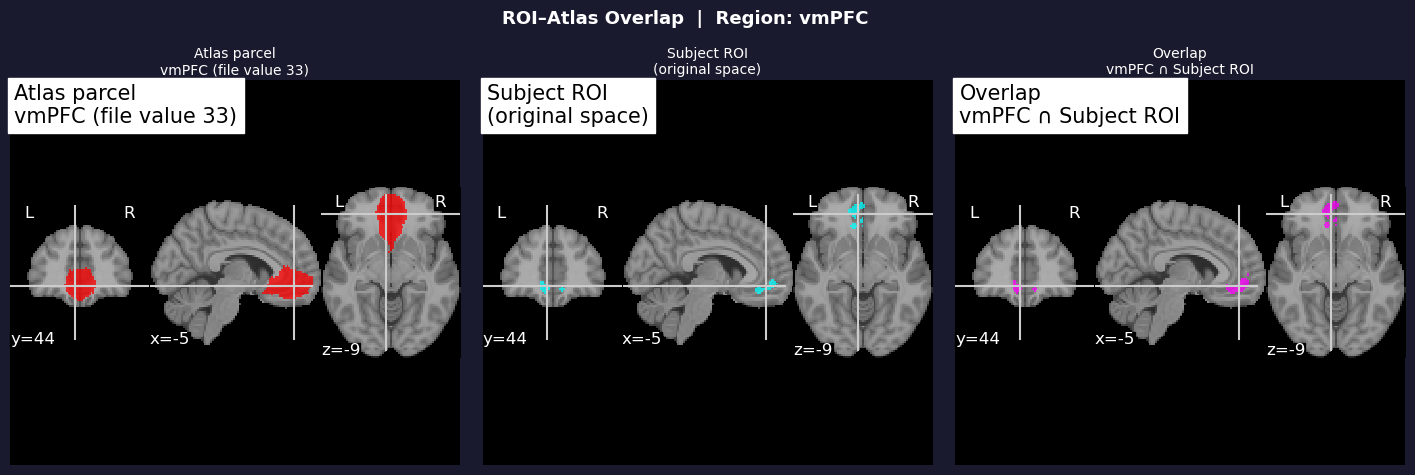

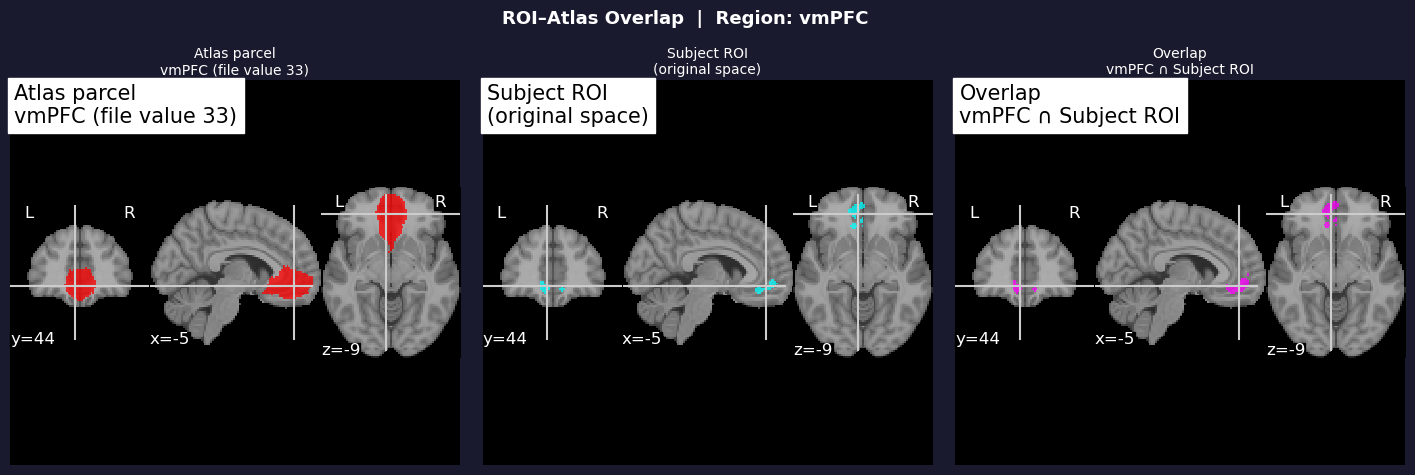

In [15]:
"""
ROI-Atlas Overlap Script v2
============================
Finds overlap between a subject ROI and the Neurosynth parcellation atlas,
identifies the named region, saves a labeled overlap NIfTI, and plots
the subject ROI alongside the full atlas parcel side by side.

Dependencies: nibabel, numpy, nilearn
Install: pip install nibabel numpy nilearn
"""

import os
import numpy as np
import nibabel as nib
from nilearn.image import resample_to_img
from nilearn import plotting

# ── Paths ─────────────────────────────────────────────────────────────────────
ROI_PATH = os.path.join(OUTPUT_DIR, 'ROI', 'roi_41_uncorrected.nii.gz')

ATLAS_PATH = "/nfs/roberts/pi/pi_il77/shared/Neurosynth Parcellation_0.nii.gz"

# Anatomical background for plots (set to None to use MNI152 template)
ANAT_PATH = None  # e.g. "/path/to/mean_epi.nii.gz"

OUT_DIR    = os.path.dirname(ROI_PATH)
OUT_NII    = os.path.join(OUT_DIR, 'roi_41_atlas_overlap.nii.gz')
OUT_REPORT = os.path.join(OUT_DIR, 'roi_41_atlas_overlap_report.txt')
OUT_PLOT   = os.path.join(OUT_DIR, 'roi_41_atlas_overlap_plot.png')

# ── Neurosynth parcellation label mapping ─────────────────────────────────────
# Keys are the raw file values (label_id + 1 in the 0-based convention).
REGION_LABELS = {
    1:  "Anterior MPFC",
    2:  "Fusiform/Parahippocampus",
    3:  "DMPFC",
    4:  "Sensorimotor/Postcentral Gyrus",
    5:  "V1",
    6:  "TPJ Posterior SMG/Angular Gyrus",
    7:  "PCC/Precuneus",
    8:  "Thalamus",
    9:  "SMA",
    10: "Precentral Gyrus",
    11: "Cerebellum (VI)",
    12: "Temporal Occipital Fusiform",
    13: "Amygdala",
    14: "Superior Temporal Gyrus",
    15: "White Matter",
    16: "TPJ Anterior SMG/Parietal Operculum",
    17: "Mid Insula",
    18: "Putamen",
    19: "Dorsal Anterior Insula",
    20: "PCC/Superior LOC",
    21: "Lateral Occipital/Temporal Occipital (V2)",
    23: "dACC",
    24: "Anterior Fronto-Parietal (DLPFC, dACC)",
    25: "Intracalcarine Cortex",
    26: "Anterior VLPFC",
    28: "Left IFG",
    29: "Hippocampus",
    30: "Dorsal Caudate",
    31: "Unknown",
    33: "vmPFC",
    35: "NAcc",
    36: "Primary Auditory",
    38: "Ventral Anterior Insula",
    40: "Superior LOC",
    43: "Cerebellum (Crus)",
    45: "DLPFC",
    46: "Right IFG/VLPFC",
    47: "Inferior LOC",
    50: "STS",
}

# ── Helpers ───────────────────────────────────────────────────────────────────

def get_region_name(file_value):
    """Return human-readable label for a raw atlas file value."""
    return REGION_LABELS.get(int(file_value), f"Region_{int(file_value)}")


def resample_roi_to_atlas(roi_img, atlas_img):
    """Resample ROI to atlas space using nearest-neighbour interpolation."""
    print("  Resampling ROI to atlas space...")
    return resample_to_img(
        roi_img, atlas_img,
        interpolation='nearest',
        force_resample=True,
        copy_header=True,
    )


def make_atlas_parcel_mask(atlas_img, file_value):
    """Return a binary NIfTI of a single atlas parcel (by raw file value)."""
    data = np.round(atlas_img.get_fdata()).astype(np.int32)
    mask = (data == int(file_value)).astype(np.int8)
    return nib.Nifti1Image(mask, atlas_img.affine, atlas_img.header)


def get_roi_centroid_mni(roi_img):
    """Return the MNI centroid of a binary (non-zero) ROI image."""
    data = roi_img.get_fdata()
    voxels = np.argwhere(data != 0)
    if voxels.size == 0:
        return None
    centroid_vox = voxels.mean(axis=0)
    return nib.affines.apply_affine(roi_img.affine, centroid_vox)


def plot_side_by_side(roi_img, parcel_img, subject_roi_img,
                      region_name, file_value, cut_coords, anat):
    """
    Three-panel figure:
      Left  — full atlas parcel
      Centre — subject ROI (in atlas space)
      Right  — overlap (parcel mask * subject ROI)
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # Build overlap mask: voxels that are in BOTH the parcel and the subject ROI
    parcel_data  = parcel_img.get_fdata()
    subject_data = roi_img.get_fdata()   # already in atlas space
    overlap_data = ((parcel_data > 0) & (subject_data != 0)).astype(np.int8)
    overlap_img  = nib.Nifti1Image(overlap_data, parcel_img.affine)

    fig = plt.figure(figsize=(18, 5))
    fig.patch.set_facecolor('#1a1a2e')
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.05)

    panels = [
        (gs[0], parcel_img,   f"Atlas parcel\n{region_name} (file value {file_value})", "autumn"),
        (gs[1], subject_roi_img, "Subject ROI\n(original space)",                       "cool"),
        (gs[2], overlap_img,  f"Overlap\n{region_name} ∩ Subject ROI",                  "spring"),
    ]

    for spec, img, title, cmap in panels:
        ax = fig.add_subplot(spec)
        display = plotting.plot_roi(
            img,
            bg_img=anat,
            display_mode='ortho',
            cut_coords=cut_coords,
            cmap=cmap,
            alpha=0.75,
            title=title,
            axes=ax,
            colorbar=False,
        )
        # Style the title
        ax.set_title(title, color='white', fontsize=10, pad=4)

    plt.suptitle(
        f"ROI–Atlas Overlap  |  Region: {region_name}",
        color='white', fontsize=13, fontweight='bold', y=1.02
    )
    return fig


# ── Main ──────────────────────────────────────────────────────────────────────

def main():
    print("Loading images...")
    roi_img   = nib.load(ROI_PATH)
    atlas_img = nib.load(ATLAS_PATH)

    print(f"  ROI   shape : {roi_img.shape}  | voxel size: {roi_img.header.get_zooms()}")
    print(f"  Atlas shape : {atlas_img.shape} | voxel size: {atlas_img.header.get_zooms()}")

    # Keep the original subject ROI for plotting in its own space
    subject_roi_img = roi_img

    # ── Align to atlas space ──────────────────────────────────────────────────
    if roi_img.shape != atlas_img.shape or not np.allclose(
            roi_img.affine, atlas_img.affine, atol=1e-3):
        print("Shapes / affines differ — resampling ROI to atlas space.")
        roi_img_r = resample_roi_to_atlas(roi_img, atlas_img)
        roi_data  = roi_img_r.get_fdata()
    else:
        print("Shapes match — no resampling needed.")
        roi_img_r = roi_img
        roi_data  = roi_img.get_fdata()

    # Use rounded integer atlas data to avoid float comparison issues
    atlas_data = np.round(atlas_img.get_fdata()).astype(np.int32)

    # ── Find overlapping atlas regions ───────────────────────────────────────
    roi_mask            = roi_data != 0
    overlap_atlas_vals  = atlas_data[roi_mask]
    overlap_atlas_vals  = overlap_atlas_vals[overlap_atlas_vals != 0]

    if overlap_atlas_vals.size == 0:
        print("\n⚠  No overlap found between the ROI and any atlas region.")
        return

    unique_regions, counts = np.unique(overlap_atlas_vals, return_counts=True)

    # ── Report ────────────────────────────────────────────────────────────────
    total_roi_vox = int(roi_mask.sum())
    lines = []
    lines.append("=" * 65)
    lines.append("ROI–Atlas Overlap Report")
    lines.append("=" * 65)
    lines.append(f"ROI file   : {ROI_PATH}")
    lines.append(f"Atlas file : {ATLAS_PATH}")
    lines.append(f"Total ROI voxels       : {total_roi_vox}")
    lines.append(f"Overlapping ROI voxels : {int(overlap_atlas_vals.size)}")
    lines.append("")
    lines.append(f"{'File value':<12} {'Region name':<42} {'Voxels':>8}  {'% of ROI':>9}")
    lines.append("-" * 75)

    for fv, cnt in sorted(zip(unique_regions, counts), key=lambda x: -x[1]):
        name = get_region_name(fv)
        pct  = 100.0 * cnt / total_roi_vox
        lines.append(f"{int(fv):<12} {name:<42} {int(cnt):>8}  {pct:>8.2f}%")

    lines.append("=" * 65)
    report_text = "\n".join(lines)
    print("\n" + report_text)

    with open(OUT_REPORT, 'w') as f:
        f.write(report_text + "\n")
    print(f"\nReport saved → {OUT_REPORT}")

    # ── Save overlap NIfTI ────────────────────────────────────────────────────
    overlap_vol = np.zeros(atlas_data.shape, dtype=np.int32)
    overlap_vol[roi_mask] = atlas_data[roi_mask]

    region_summary = ", ".join(get_region_name(fv) for fv in unique_regions)
    overlap_img    = nib.Nifti1Image(overlap_vol, atlas_img.affine, atlas_img.header)
    overlap_img.header['descrip'] = f"Overlap: {region_summary}"[:79].encode()

    nib.save(overlap_img, OUT_NII)
    print(f"Overlap NIfTI saved → {OUT_NII}")
    print(f"  Regions: {region_summary}")

    # ── Visualisation ─────────────────────────────────────────────────────────
    # Use the centroid of the subject ROI as the cut-coord anchor
    centroid = get_roi_centroid_mni(subject_roi_img)
    if centroid is None:
        centroid = (0, 0, 0)
    cut_coords = tuple(centroid.round(0).astype(int))
    print(f"\nPlotting with cut_coords (MNI): {cut_coords}")

    # Background: use provided anat, or fall back to MNI152 template
    if ANAT_PATH and os.path.isfile(ANAT_PATH):
        anat = nib.load(ANAT_PATH)
    else:
        from nilearn.datasets import load_mni152_template
        anat = load_mni152_template(resolution=2)

    # Dominant overlapping parcel (most voxels)
    dominant_fv   = unique_regions[np.argmax(counts)]
    dominant_name = get_region_name(dominant_fv)
    parcel_img    = make_atlas_parcel_mask(atlas_img, dominant_fv)

    fig = plot_side_by_side(
        roi_img_r,         # subject ROI in atlas space (for overlap calc)
        parcel_img,        # full atlas parcel
        subject_roi_img,   # original subject ROI (for middle panel)
        dominant_name,
        int(dominant_fv),
        cut_coords,
        anat,
    )

    fig.savefig(OUT_PLOT, dpi=150, bbox_inches='tight',
                facecolor='#1a1a2e')
    print(f"Plot saved → {OUT_PLOT}")

    # Also display inline if running in a notebook
    try:
        get_ipython  # noqa: F821
        from IPython.display import display
        display(fig)
    except NameError:
        import matplotlib.pyplot as plt
        plt.show()


if __name__ == "__main__":
    main()

## Making Spherical ROI of X mm radius given above findings

ROI: roi41sphere_r10mm_x4_y43_z9
Sphere center (MNI): (-4, 43, -9)
Sphere radius (mm): 10
Number of voxels in spherical ROI mask: 528
[OK] Saved ROI mask NIfTI → /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41sphere_r10mm_x4_y43_z9_ROIMaskOverlay.jpeg


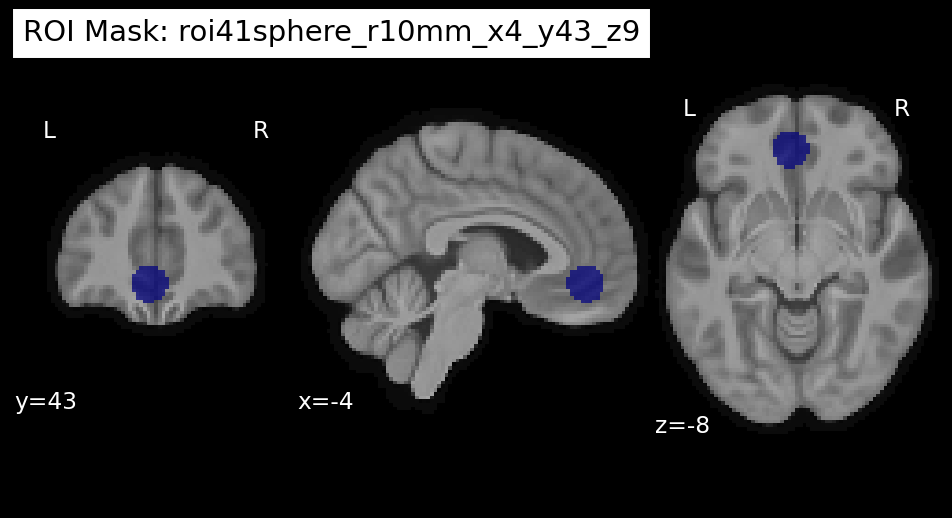


One-sample ROI test (rank-regression Value contrast)
Contrast (key): Value
Contrast (label): Value
ROI: roi41sphere_r10mm_x4_y43_z9
ROI mask: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz
N subjects: 50
Mean ROI signal: 0.047359 (SD=0.087979, SEM=0.012442)
t(49) = 3.806, p = 0.0003927
Cohen's d = 0.538
95% CI for mean: [0.022356, 0.072363]


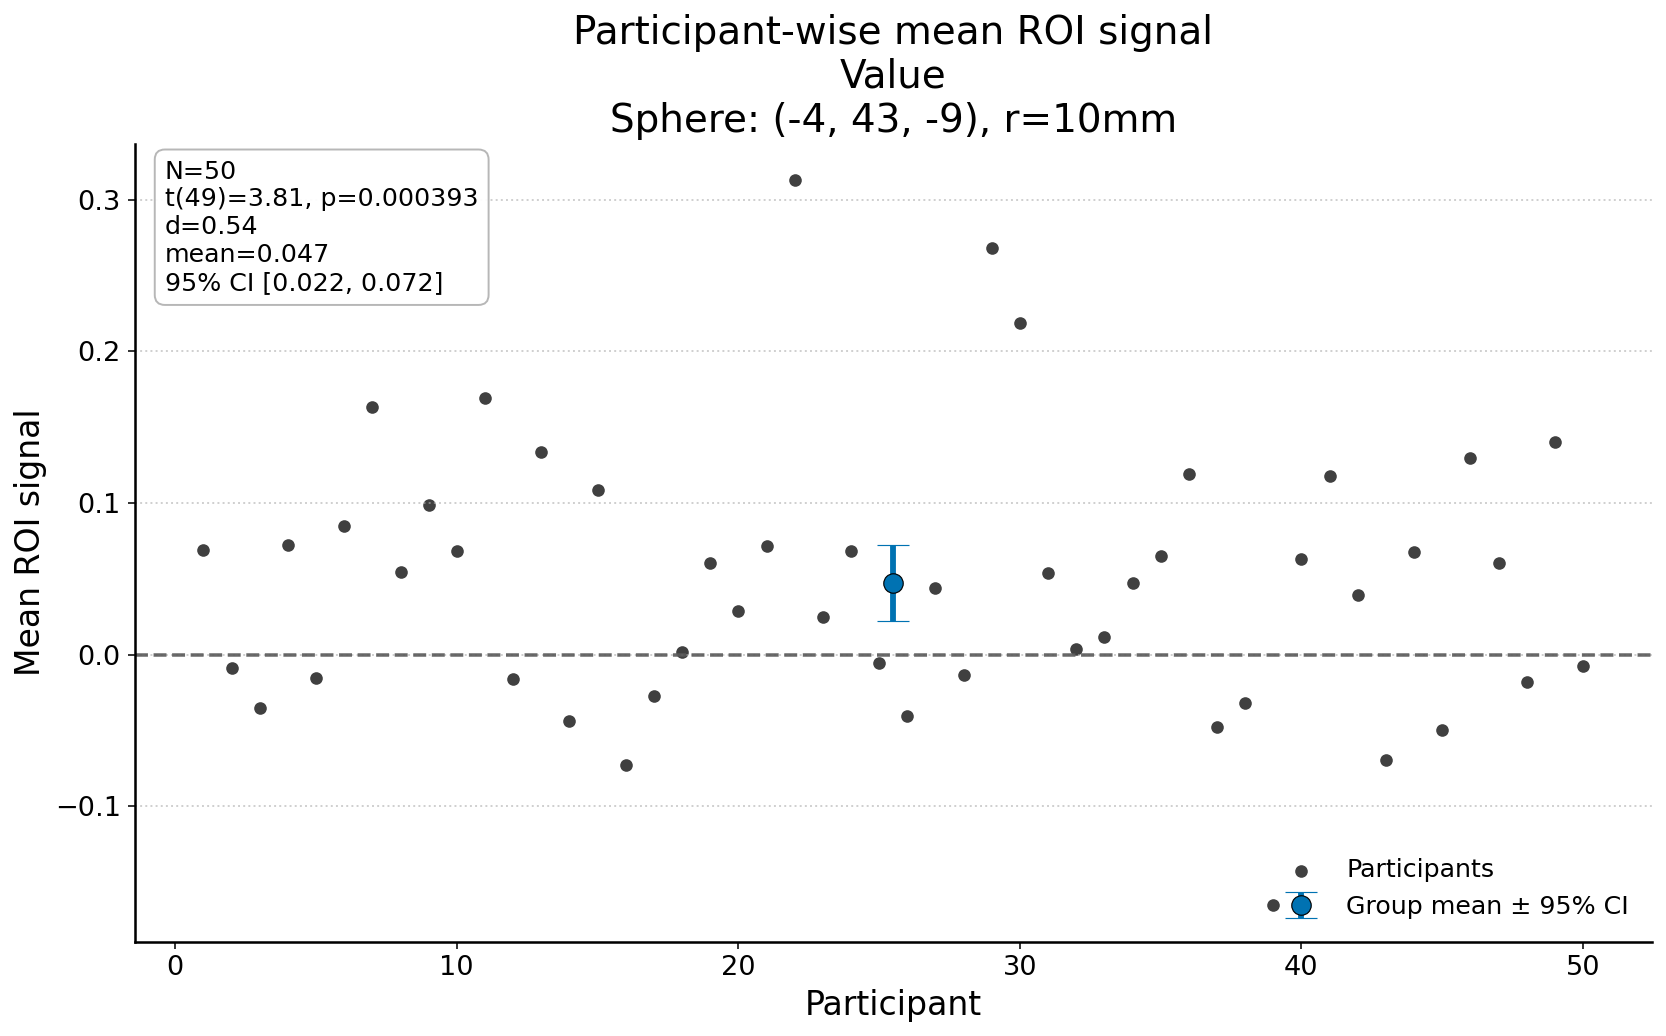

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41sphere_r10mm_x4_y43_z9_Value_ParticipantScatter_MeanCI.jpeg


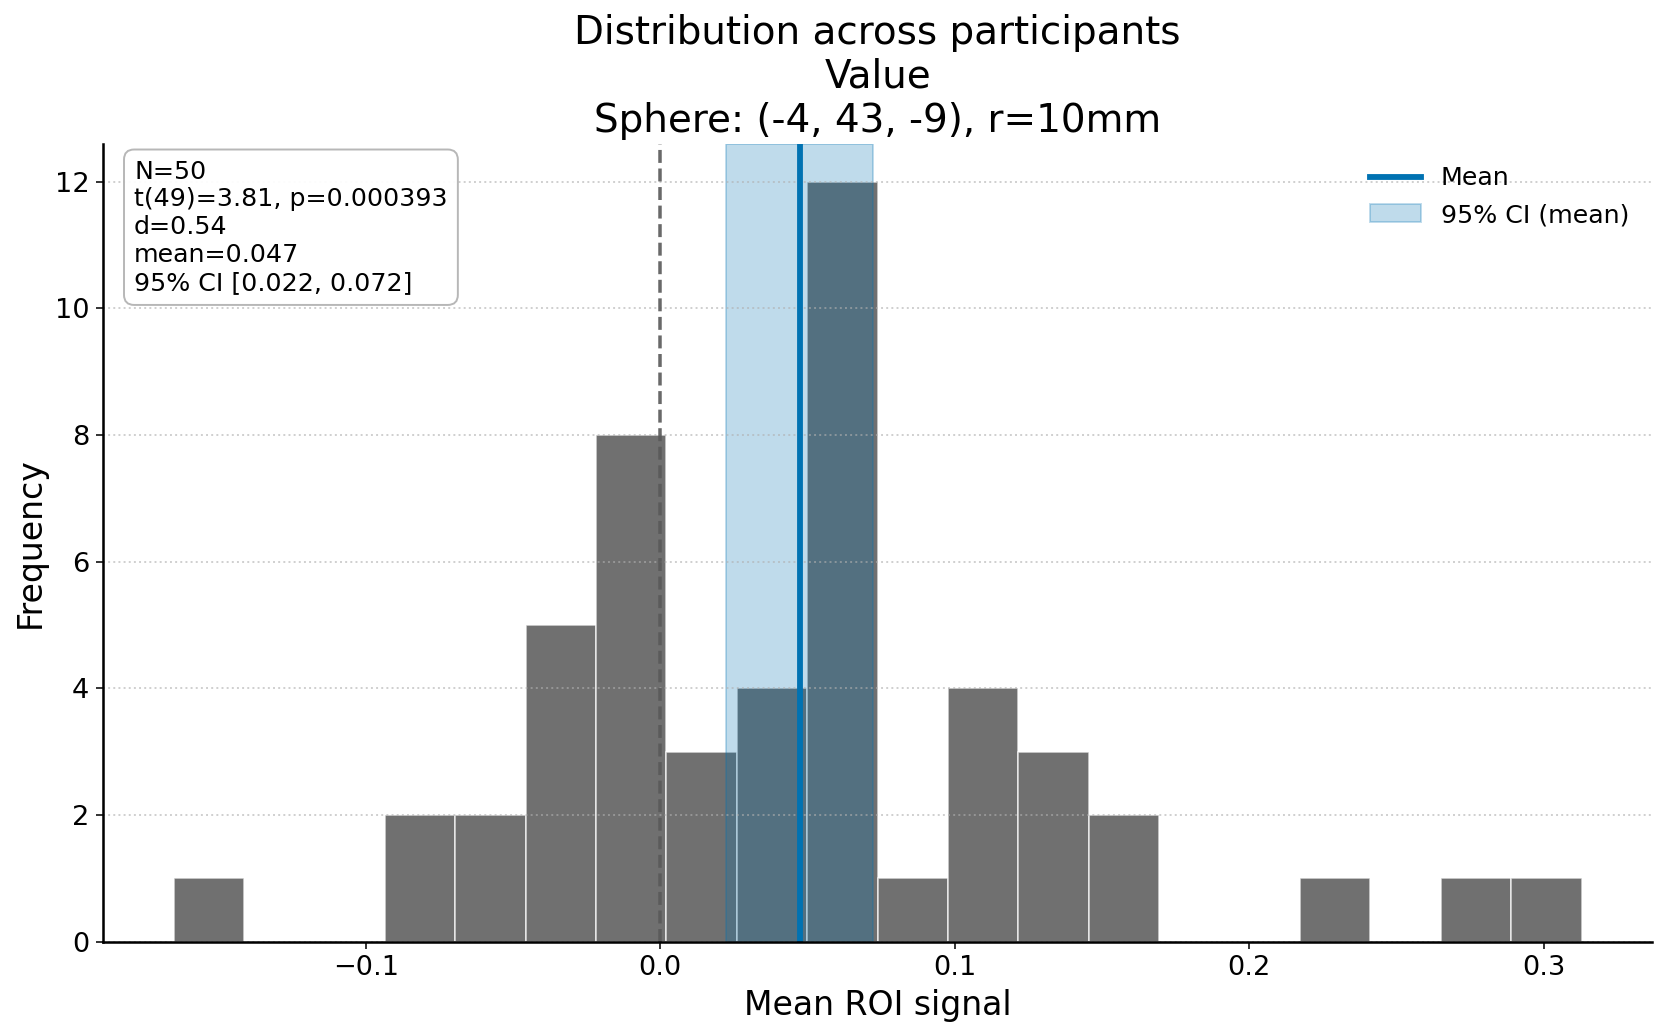

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41sphere_r10mm_x4_y43_z9_Value_Histogram_MeanCI.jpeg


In [14]:
# Rating rank-regression ROI test — TRUE sphere + formatted/saved like your decoupled scripts
# - TRUE spherical mask in mm-space (not voxel dilation)
# - ROI overlay saved (no colorbar)
# - One-sample t-test vs 0 with 95% CI + Cohen's d
# - Participant scatter (mean ± 95% CI) + histogram saved
#
# Saves figures to:
# /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures
#
# Saves ROI mask to:
# OUTPUT_DIR/ROI/

import os
import re
import numpy as np
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers: stats + CI + effect size + filenames
# -----------------------
def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def create_true_sphere_mask_mni(center_mni_xyz, radius_mm, reference_img):
    """
    Create a TRUE spherical mask in mm-space (not voxel dilation).
    Works in the space of reference_img (shape + affine).
    """
    center_mni_xyz = np.asarray(center_mni_xyz, dtype=float)

    ijk = np.indices(reference_img.shape).reshape(3, -1).T  # (N, 3)
    xyz = nib.affines.apply_affine(reference_img.affine, ijk)  # (N, 3) mm

    dist = np.sqrt(((xyz - center_mni_xyz) ** 2).sum(axis=1))
    mask_flat = dist <= float(radius_mm)
    mask_3d = mask_flat.reshape(reference_img.shape)

    return nib.Nifti1Image(mask_3d.astype(np.int8), reference_img.affine, reference_img.header)

# -----------------------
# Settings (readability)
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.3,
})

MEAN_COLOR = "#0072B2"   # Okabe–Ito blue
ZERO_COLOR = "0.35"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value"
functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_all_sub_4d.nii.gz")

anat_img = load_img(str(MEAN_ANAT))  # reference for sphere + bg for overlay

coords = (-4, 43, -9)  # MNI mm (ROI41 peak per your comment)
radius = 10             # mm

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label = "roi41sphere_r10mm_x4_y43_z9"
roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# -----------------------
# Output folders
# -----------------------
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

ROI_OUT_DIR = os.path.join(str(OUTPUT_DIR), "ROI")
os.makedirs(ROI_OUT_DIR, exist_ok=True)

# -----------------------
# Load functional
# -----------------------
functional_img = nib.load(functional_img_path)

# -----------------------
# Build TRUE spherical ROI mask (mm-space)
# -----------------------
spherical_roi_mask = create_true_sphere_mask_mni(coords, radius, anat_img)
n_vox = int(np.sum(spherical_roi_mask.get_fdata() > 0))
print(f"ROI: {roi_label}")
print(f"Sphere center (MNI): {coords}")
print(f"Sphere radius (mm): {radius}")
print(f"Number of voxels in spherical ROI mask: {n_vox}")

# -----------------------
# Save ROI mask NIfTI
# -----------------------
roi_mask_path = os.path.join(
    ROI_OUT_DIR,
    f"sphere_r{radius}mm_x{coords[0]}_y{coords[1]}_z{coords[2]}_mask_RANKREGRESSION.nii.gz"
)
nib.save(spherical_roi_mask, roi_mask_path)
print(f"[OK] Saved ROI mask NIfTI → {roi_mask_path}")

# -----------------------
# ROI mask overlay (SAVE; no colorbar)
# -----------------------
display = plotting.plot_roi(
    spherical_roi_mask,
    bg_img=anat_img,
    title=f"ROI Mask: {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)

roi_plot_title = "ROIMaskOverlay"
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_{roi_plot_title}.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# Optional inline display
disp_inline = plotting.plot_roi(
    spherical_roi_mask,
    bg_img=anat_img,
    title=f"ROI Mask: {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)
plt.show()

# -----------------------
# Extract mean signal per subject
# -----------------------
nifti_masker = input_data.NiftiMasker(mask_img=spherical_roi_mask, standardize=False)
roi_vox = nifti_masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
mean_signal_per_subject = np.asarray(roi_vox.mean(axis=1)).ravel()

x = mean_signal_per_subject.astype(float)
x = x[~np.isnan(x)]

n = int(x.size)
df = n - 1

# -----------------------
# Stats: one-sample vs 0 with 95% CI + Cohen's d
# -----------------------
group_mean = float(np.mean(x))
group_sd = float(np.std(x, ddof=1))
group_sem = float(stats.sem(x))

t_statistic, p_value = stats.ttest_1samp(x, 0.0, nan_policy="omit")
t_statistic = float(t_statistic)
p_value = float(p_value)

d = cohens_d_onesample(x, mu0=0.0)
_, (ci_lo, ci_hi) = mean_ci_t(x, confidence=0.95)

print("\nOne-sample ROI test (rank-regression Value contrast)")
print(f"Contrast (key): {contrast_key}")
print(f"Contrast (label): {contrast_label}")
print(f"ROI: {roi_label}")
print(f"ROI mask: {roi_mask_path}")
print(f"N subjects: {n}")
print(f"Mean ROI signal: {group_mean:.6f} (SD={group_sd:.6f}, SEM={group_sem:.6f})")
print(f"t({df}) = {t_statistic:.3f}, p = {p_value:.4g}")
print(f"Cohen's d = {d:.3f}")
print(f"95% CI for mean: [{ci_lo:.6f}, {ci_hi:.6f}]")

stats_text = (
    f"N={n}\n"
    f"t({df})={t_statistic:.2f}, p={p_value:.3g}\n"
    f"d={d:.2f}\n"
    f"mean={group_mean:.3f}\n"
    f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]"
)

# -----------------------
# Plot 1: participant points + mean ± 95% CI (SAVE)
# -----------------------
fig1, ax1 = plt.subplots(figsize=(12, 7.5))
x_subjects = np.arange(1, n + 1)

ax1.scatter(
    x_subjects, x,
    color="black", alpha=0.75, s=42, linewidths=0,
    label="Participants"
)

ax1.errorbar(
    x=float(np.mean(x_subjects)),
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.0,
    capsize=8,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.6,
    label="Group mean ± 95% CI"
)

ax1.axhline(y=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
ax1.set_xlabel("Participant")
ax1.set_ylabel("Mean ROI signal")

plot1_title = "ParticipantScatter_MeanCI"
ax1.set_title(f"Participant-wise mean ROI signal\n{contrast_label}\nSphere: {coords}, r={radius}mm")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax1.text(
    0.02, 0.98, stats_text,
    transform=ax1.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax1.legend(frameon=False, loc="lower right")
plt.tight_layout()

fname1 = f"{roi_slug}_{contrast_slug}_{plot1_title}.jpeg"
out1 = os.path.join(FIG_DIR, fname1)
fig1.savefig(out1, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out1}")

# -----------------------
# Plot 2: histogram + mean and CI (SAVE)
# -----------------------
fig2, ax2 = plt.subplots(figsize=(12, 7.5))

ax2.hist(x, bins=20, color="0.25", alpha=0.75, edgecolor="white", linewidth=0.8)
ax2.axvline(x=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)

ax2.axvline(group_mean, color=MEAN_COLOR, linewidth=3.0, label="Mean")
ax2.axvspan(ci_lo, ci_hi, color=MEAN_COLOR, alpha=0.25, label="95% CI (mean)")

ax2.set_xlabel("Mean ROI signal")
ax2.set_ylabel("Frequency")

plot2_title = "Histogram_MeanCI"
ax2.set_title(f"Distribution across participants\n{contrast_label}\nSphere: {coords}, r={radius}mm")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax2.text(
    0.02, 0.98, stats_text,
    transform=ax2.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax2.legend(frameon=False, loc="upper right")
plt.tight_layout()

fname2 = f"{roi_slug}_{contrast_slug}_{plot2_title}.jpeg"
out2 = os.path.join(FIG_DIR, fname2)
fig2.savefig(out2, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out2}")

ROI: 10-mm sphere MNI [-4, 43, -9]
Sphere center (MNI): (-4, 43, -9)
Sphere radius (mm): 10
Number of voxels in spherical ROI mask: 528
[OK] Saved ROI mask NIfTI → /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz


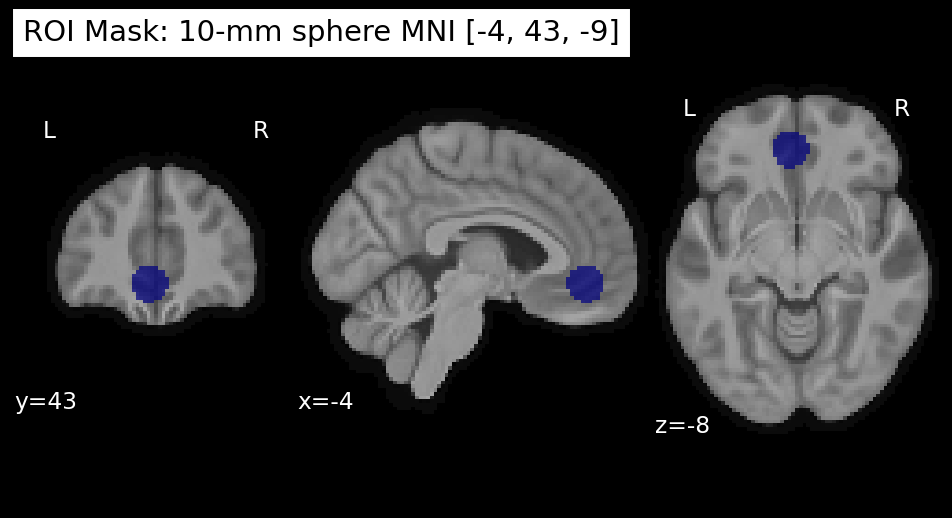

[OK] Saved ROI overlay: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41sphere_r10mm_ROIMaskOverlay.jpeg

One-sample ROI test (rank-regression Value contrast)
Contrast (key): Value
Contrast (label): Value
ROI: 10-mm sphere MNI [-4, 43, -9]
ROI mask: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz
N subjects: 50
Mean ROI signal: 0.047359 (SD=0.087979, SEM=0.012442)
t(49) = 3.806, p = 0.0003927
Cohen's d = 0.538
95% CI for mean: [0.022356, 0.072363]


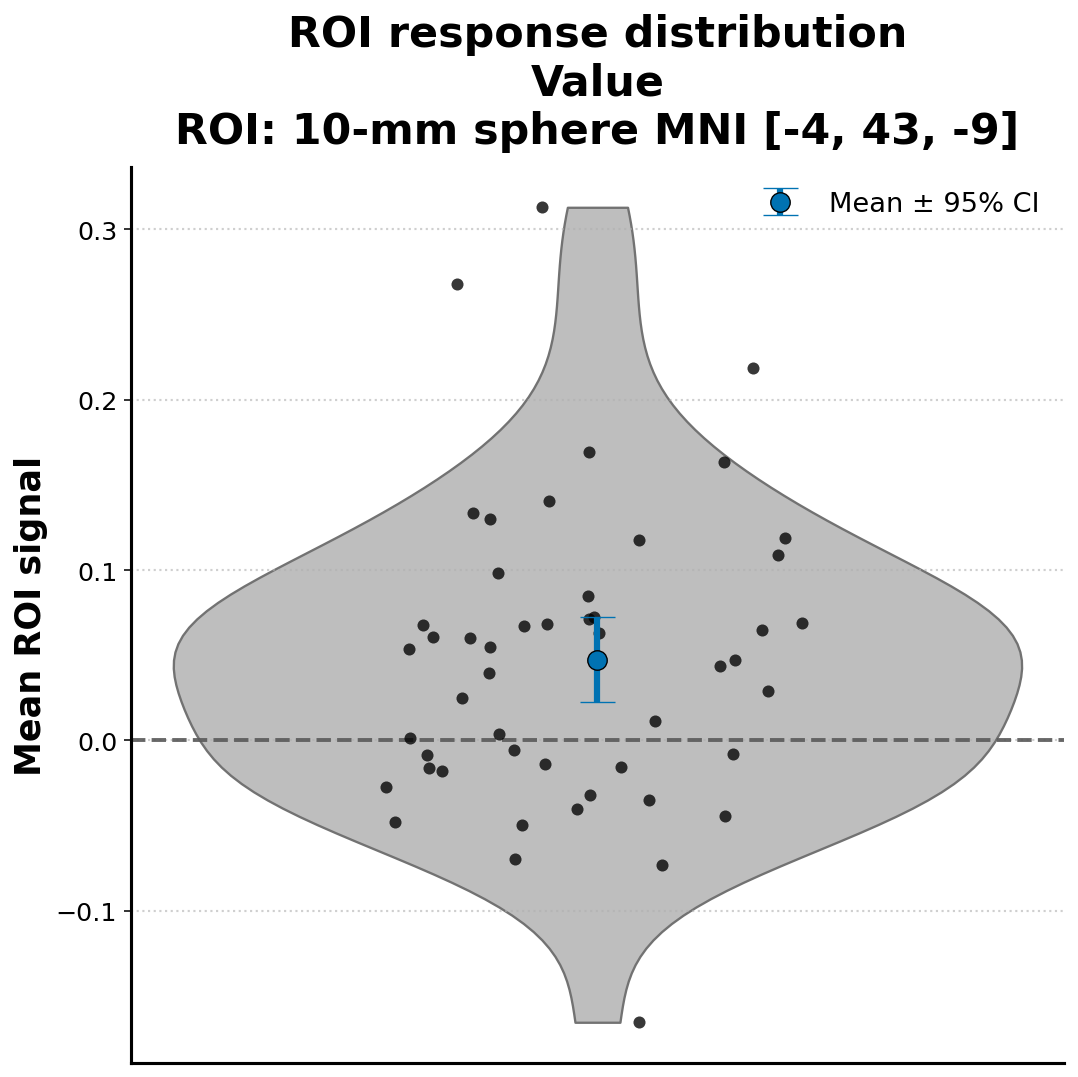

[OK] Saved violin: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/roi41sphere_r10mm_Value_ViolinPoints_MeanCI.jpeg


In [13]:
# Rating rank-regression ROI test — TRUE sphere + ROI overlay + VIOLIN (mean ± 95% CI)
# - TRUE spherical mask in mm-space (not voxel dilation)
# - ROI overlay shown + saved (no colorbar)
# - One-sample t-test vs 0 with 95% CI + Cohen's d
# - Violin with individual subject points + mean ± 95% CI (shown + saved)
#
# Saves figures to:
# /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures
#
# Saves ROI mask to:
# OUTPUT_DIR/ROI/

import os
import re
import numpy as np
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt

from nilearn import plotting
from nilearn.image import load_img
from nilearn import input_data
from scipy import stats


# -----------------------
# Helpers: stats + CI + effect size + filenames
# -----------------------
def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def create_true_sphere_mask_mni(center_mni_xyz, radius_mm, reference_img):
    """
    Create a TRUE spherical mask in mm-space (not voxel dilation).
    Works in the space of reference_img (shape + affine).
    """
    center_mni_xyz = np.asarray(center_mni_xyz, dtype=float)

    ijk = np.indices(reference_img.shape).reshape(3, -1).T  # (N, 3)
    xyz = nib.affines.apply_affine(reference_img.affine, ijk)  # (N, 3) mm

    dist = np.sqrt(((xyz - center_mni_xyz) ** 2).sum(axis=1))
    mask_flat = dist <= float(radius_mm)
    mask_3d = mask_flat.reshape(reference_img.shape)

    return nib.Nifti1Image(mask_3d.astype(np.int8), reference_img.affine, reference_img.header)


# -----------------------
# Settings (readability; larger/bolder)
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "axes.linewidth": 1.6,
})

MEAN_COLOR = "#0072B2"
ZERO_COLOR = "0.35"
VIOLIN_COLOR = "#BEBEBE"


# -----------------------
# Inputs
# -----------------------
contrast_key = "Value"
functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_all_sub_4d.nii.gz")

anat_img = load_img(str(MEAN_ANAT))  # reference for sphere + bg for overlay

coords = (-4, 43, -9)  # MNI mm
radius = 10            # mm

try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label_plot = f"10-mm sphere MNI [{coords[0]}, {coords[1]}, {coords[2]}]"
roi_slug = safe_filename("roi41sphere_r10mm")
contrast_slug = safe_filename(contrast_label)

FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

ROI_OUT_DIR = os.path.join(str(OUTPUT_DIR), "ROI")
os.makedirs(ROI_OUT_DIR, exist_ok=True)


# -----------------------
# Load functional
# -----------------------
functional_img = nib.load(functional_img_path)


# -----------------------
# Build TRUE spherical ROI mask (mm-space) + save
# -----------------------
spherical_roi_mask = create_true_sphere_mask_mni(coords, radius, anat_img)
n_vox = int(np.sum(spherical_roi_mask.get_fdata() > 0))

print(f"ROI: {roi_label_plot}")
print(f"Sphere center (MNI): {coords}")
print(f"Sphere radius (mm): {radius}")
print(f"Number of voxels in spherical ROI mask: {n_vox}")

roi_mask_path = os.path.join(
    ROI_OUT_DIR,
    f"sphere_r{radius}mm_x{coords[0]}_y{coords[1]}_z{coords[2]}_mask_RANKREGRESSION.nii.gz"
)
nib.save(spherical_roi_mask, roi_mask_path)
print(f"[OK] Saved ROI mask NIfTI → {roi_mask_path}")


# -----------------------
# ROI mask overlay (SHOW + SAVE; no colorbar)
# -----------------------
roi_display = plotting.plot_roi(
    spherical_roi_mask,
    bg_img=anat_img,
    title=f"ROI Mask: {roi_label_plot}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)

plotting.show()

roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
roi_display.savefig(roi_out, dpi=600)
roi_display.close()
print(f"[OK] Saved ROI overlay: {roi_out}")


# -----------------------
# Extract mean signal per subject
# -----------------------
nifti_masker = input_data.NiftiMasker(mask_img=spherical_roi_mask, standardize=False)
roi_vox = nifti_masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
x = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)
x = x[~np.isnan(x)]

n = int(x.size)
df = n - 1


# -----------------------
# Stats: one-sample vs 0 with 95% CI + Cohen's d
# -----------------------
group_mean = float(np.mean(x))
group_sd = float(np.std(x, ddof=1))
group_sem = float(stats.sem(x))

t_statistic, p_value = stats.ttest_1samp(x, 0.0, nan_policy="omit")
t_statistic = float(t_statistic)
p_value = float(p_value)

d = cohens_d_onesample(x, mu0=0.0)
_, (ci_lo, ci_hi) = mean_ci_t(x, confidence=0.95)

print("\nOne-sample ROI test (rank-regression Value contrast)")
print(f"Contrast (key): {contrast_key}")
print(f"Contrast (label): {contrast_label}")
print(f"ROI: {roi_label_plot}")
print(f"ROI mask: {roi_mask_path}")
print(f"N subjects: {n}")
print(f"Mean ROI signal: {group_mean:.6f} (SD={group_sd:.6f}, SEM={group_sem:.6f})")
print(f"t({df}) = {t_statistic:.3f}, p = {p_value:.4g}")
print(f"Cohen's d = {d:.3f}")
print(f"95% CI for mean: [{ci_lo:.6f}, {ci_hi:.6f}]")


# -----------------------
# Violin: subject points + mean ± 95% CI (SHOW + SAVE)
# -----------------------
figV, axV = plt.subplots(figsize=(7.8, 7.8))

sns.violinplot(
    y=x,
    ax=axV,
    color=VIOLIN_COLOR,
    inner=None,
    cut=0,
    linewidth=1.2
)

sns.stripplot(
    y=x,
    ax=axV,
    color="black",
    alpha=0.78,
    jitter=0.20,
    size=6.2,
    zorder=4
)

axV.errorbar(
    x=0,
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.2,
    capsize=9,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.7,
    zorder=5,
    label="Mean ± 95% CI"
)

axV.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=2.0, alpha=0.9)
axV.set_xticks([])
axV.set_xlabel("")
axV.set_ylabel("Mean ROI signal")
axV.set_title(f"ROI response distribution\n{contrast_label}\nROI: {roi_label_plot}", pad=12)

axV.spines["top"].set_visible(False)
axV.spines["right"].set_visible(False)
axV.grid(True, axis="y", linestyle=":", linewidth=1.1, alpha=0.6)
axV.legend(frameon=False, loc="upper right")

plt.tight_layout()
violin_out = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_ViolinPoints_MeanCI.jpeg")
figV.savefig(violin_out, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved violin: {violin_out}")

ROI voxels: 528

Strongly Like
  N = 45
  Mean = -0.272440
  SEM = 0.149150
  T-statistic = -1.826619
  P-value = 0.0745461

Like
  N = 45
  Mean = -0.687148
  SEM = 0.124916
  T-statistic = -5.500870
  P-value = 1.81667e-06

Neutral
  N = 45
  Mean = -0.813845
  SEM = 0.165519
  T-statistic = -4.916939
  P-value = 1.26792e-05

Dislike
  N = 45
  Mean = -0.799164
  SEM = 0.148069
  T-statistic = -5.397230
  P-value = 2.57148e-06

Strongly Dislike
  N = 45
  Mean = -0.371996
  SEM = 0.237622
  T-statistic = -1.565496
  P-value = 0.124631
Strongly Like vs Like: paired t = 4.2707, p = 0.000102444 (n=45)
Strongly Like vs Neutral: paired t = 3.7694, p = 0.000483789 (n=45)
Strongly Like vs Dislike: paired t = 4.4257, p = 6.25452e-05 (n=45)
Strongly Like vs Strongly Dislike: paired t = 0.3978, p = 0.692729 (n=45)
Like vs Neutral: paired t = 1.0099, p = 0.318076 (n=45)
Like vs Dislike: paired t = 1.2552, p = 0.216041 (n=45)
Like vs Strongly Dislike: paired t = -1.4305, p = 0.159638 (n=45)
Neut

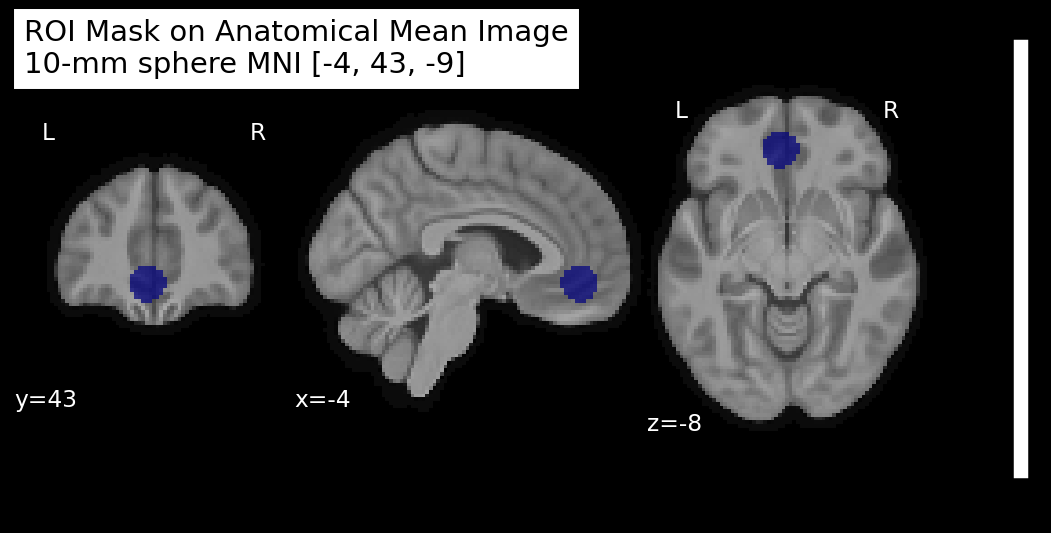

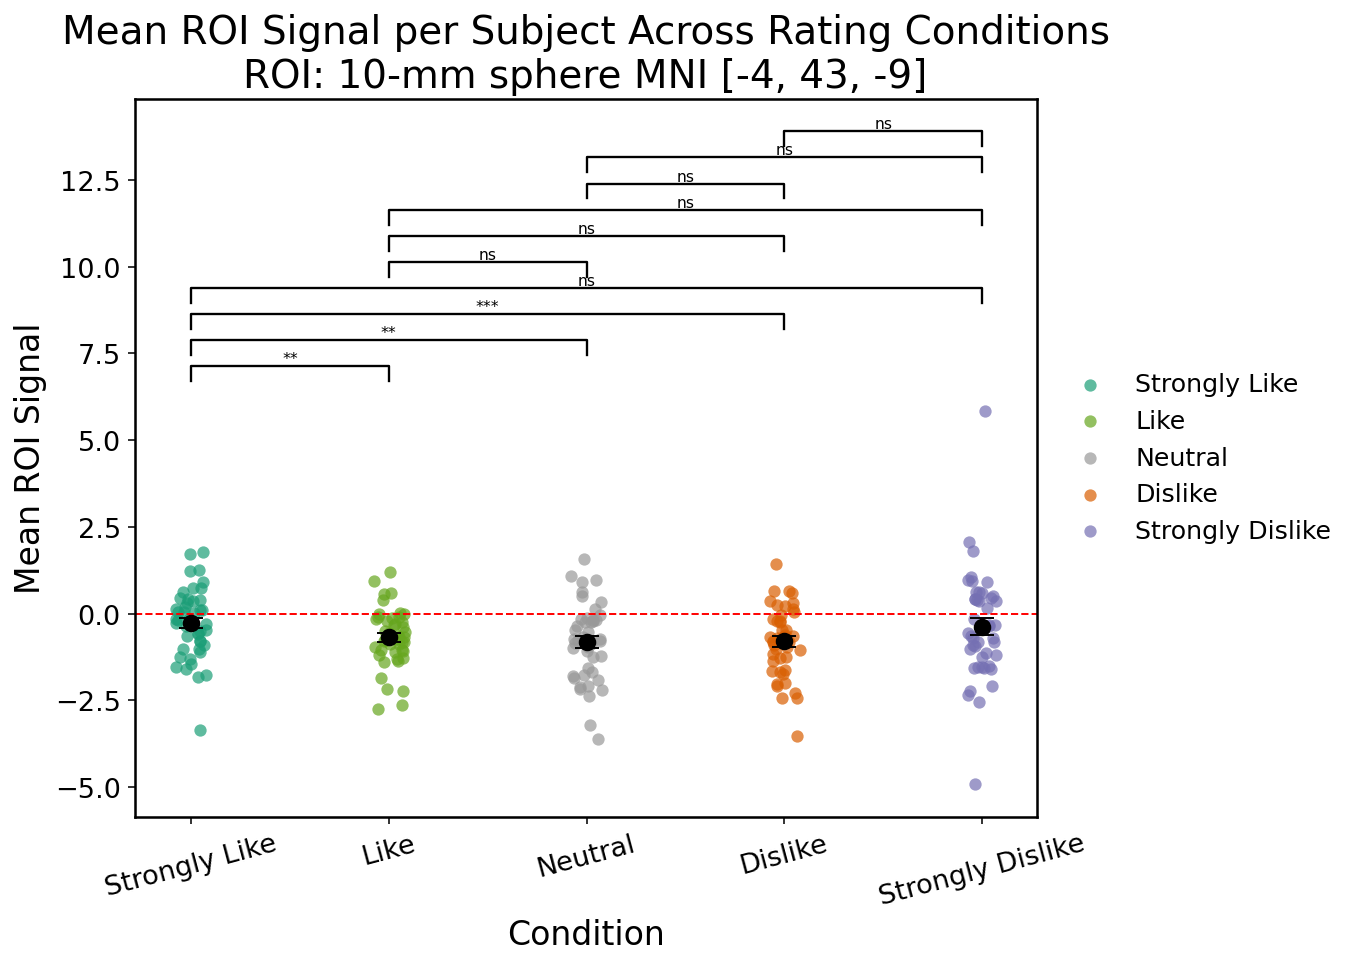

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/10-mm_sphere_MNI_-4_43_-9_OverlaidHistograms.jpeg


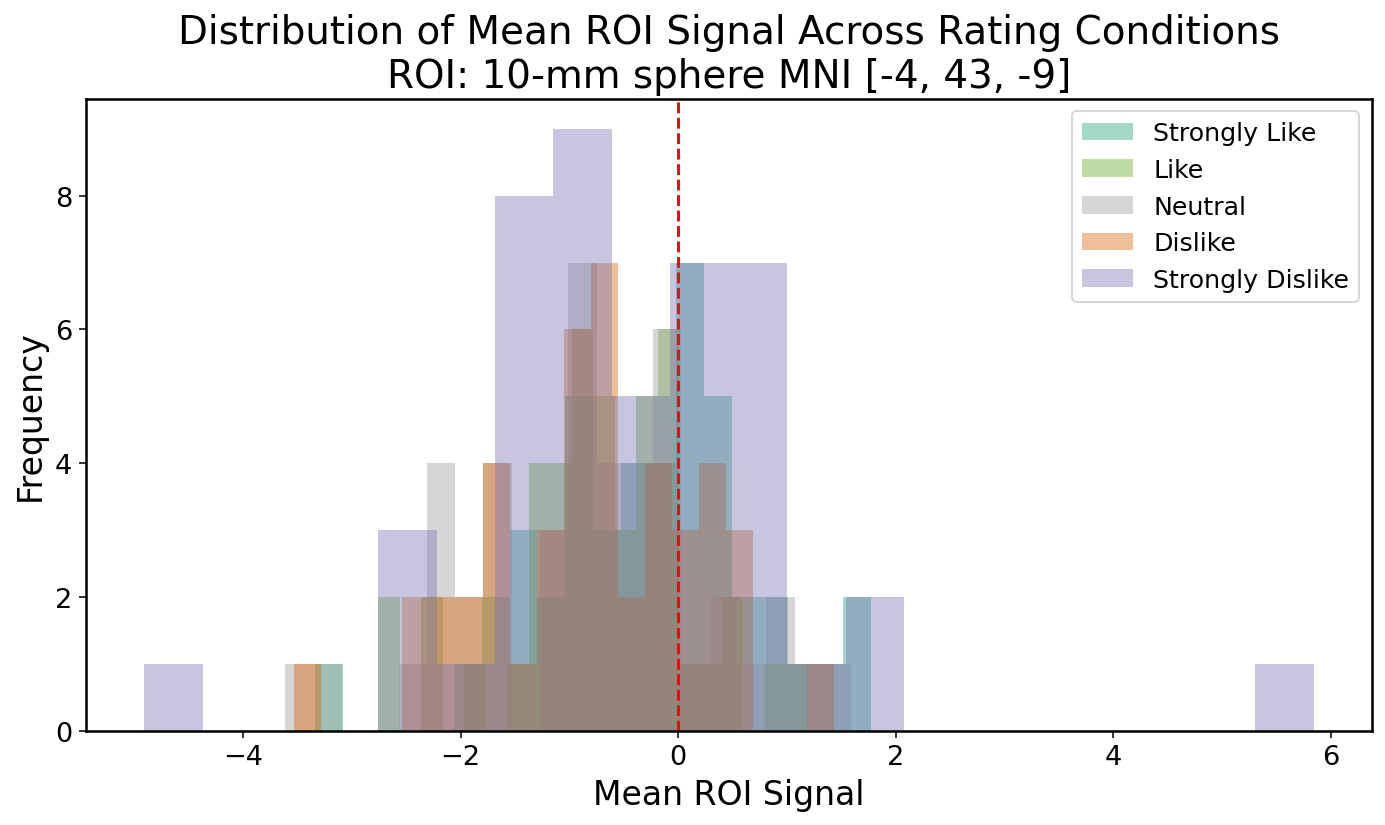

In [10]:
import os
import itertools
import numpy as np
import nibabel as nib
from nilearn import input_data, plotting
from scipy import stats
import matplotlib.pyplot as plt
import re

# --------------------------------------------------
# Define paths
# --------------------------------------------------
contrast_paths = {
    "Strongly Like": os.path.join(
        "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output",
        "imaging", "map_correction", "rating", "OLDGLM",
        "none_glm_con0002_all_sub.nii.gz"
    ),
    "Like": os.path.join(
        "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output",
        "imaging", "map_correction", "rating", "OLDGLM",
        "none_glm_con0003_all_sub.nii.gz"
    ),
    "Neutral": os.path.join(
        "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output",
        "imaging", "map_correction", "rating", "OLDGLM",
        "none_glm_con0004_all_sub.nii.gz"
    ),
    "Dislike": os.path.join(
        "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output",
        "imaging", "map_correction", "rating", "OLDGLM",
        "none_glm_con0005_all_sub.nii.gz"
    ),
    "Strongly Dislike": os.path.join(
        "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output",
        "imaging", "map_correction", "rating", "OLDGLM",
        "none_glm_con0006_all_sub.nii.gz"
    ),
}

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"

# Where to save figures
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Force consistent ROI naming in titles + saved filenames
ROI_LABEL_FOR_FIGS = "10-mm sphere MNI [-4, 43, -9]"

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

roi_slug = safe_filename(ROI_LABEL_FOR_FIGS)

# --------------------------------------------------
# Load ROI mask (saved sphere) + a reference image for geometry/QC
# --------------------------------------------------
roi_mask_img = nib.load(roi_mask_path)

reference_path = next(path for path in contrast_paths.values() if path not in ["", None])
reference_img = nib.load(reference_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# Optional ROI visualization (anat_img must already exist in your notebook)
plotting.plot_roi(
    roi_mask_img,
    anat_img,
    title=f"ROI Mask on Anatomical Mean Image\n{ROI_LABEL_FOR_FIGS}",
    display_mode="ortho",
    draw_cross=False,
)

# --------------------------------------------------
# Initialize masker
# --------------------------------------------------
nifti_masker = input_data.NiftiMasker(mask_img=roi_mask_img, standardize=False)
nifti_masker.fit()  # optional; transform() works after fit

# --------------------------------------------------
# Colors for conditions
# --------------------------------------------------
condition_colors = {
    "Strongly Like": "#1b9e77",
    "Like": "#66a61e",
    "Neutral": "#999999",
    "Dislike": "#d95f02",
    "Strongly Dislike": "#7570b3",
}

# --------------------------------------------------
# Extract ROI signal and run one-sample t-test for each condition
# --------------------------------------------------
results = {}

for condition, functional_img_path in contrast_paths.items():
    if functional_img_path in ["", None]:
        print(f"Skipping {condition}: no file path provided.")
        continue

    if not os.path.exists(functional_img_path):
        print(f"Skipping {condition}: file not found -> {functional_img_path}")
        continue

    functional_img = nib.load(functional_img_path)

    # If you ever need to ensure mask/functional alignment, uncomment:
    # from nilearn.image import resample_to_img
    # roi_for_func = resample_to_img(roi_mask_img, functional_img, interpolation="nearest")
    # time_series = input_data.NiftiMasker(mask_img=roi_for_func, standardize=False).fit_transform(functional_img)

    time_series = nifti_masker.transform(functional_img)  # (n_subjects, n_voxels)
    mean_signal_per_subject = time_series.mean(axis=1)

    t_statistic, p_value = stats.ttest_1samp(mean_signal_per_subject, 0.0, nan_policy="omit")

    results[condition] = {
        "mean_signal": mean_signal_per_subject,
        "t_statistic": float(t_statistic),
        "p_value": float(p_value),
        "mean": float(np.mean(mean_signal_per_subject)),
        "sem": float(stats.sem(mean_signal_per_subject, nan_policy="omit")),
        "n": int(np.sum(np.isfinite(mean_signal_per_subject))),
    }

    print(f"\n{condition}")
    print(f"  N = {results[condition]['n']}")
    print(f"  Mean = {results[condition]['mean']:.6f}")
    print(f"  SEM = {results[condition]['sem']:.6f}")
    print(f"  T-statistic = {results[condition]['t_statistic']:.6f}")
    print(f"  P-value = {results[condition]['p_value']:.6g}")

# --------------------------------------------------
# Pairwise significance tests (paired)
# --------------------------------------------------
condition_order = list(results.keys())
pairwise_pvals = {}

for c1, c2 in itertools.combinations(condition_order, 2):
    x = np.asarray(results[c1]["mean_signal"], dtype=float)
    y = np.asarray(results[c2]["mean_signal"], dtype=float)

    # Paired test requires matched subjects; also drop any NaNs pairwise
    ok = np.isfinite(x) & np.isfinite(y)
    x2, y2 = x[ok], y[ok]

    if x2.size == 0 or y2.size == 0:
        print(f"Skipping {c1} vs {c2}: no finite paired observations.")
        continue

    t_stat, p_val = stats.ttest_rel(x2, y2, nan_policy="omit")
    pairwise_pvals[(c1, c2)] = {"t": float(t_stat), "p": float(p_val)}
    print(f"{c1} vs {c2}: paired t = {t_stat:.4f}, p = {p_val:.6g} (n={x2.size})")

# Bonferroni correction (optional)
m = len(pairwise_pvals)
pairwise_pvals_corr = {}
for k, v in pairwise_pvals.items():
    p_corr = min(v["p"] * m, 1.0) if m > 0 else np.nan
    pairwise_pvals_corr[k] = {**v, "p_corr": p_corr}

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# --------------------------------------------------
# Plot 1: individual subject points + mean±SEM + significance brackets
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

for i, (condition, res) in enumerate(results.items(), start=1):
    y = np.asarray(res["mean_signal"], dtype=float)
    y = y[np.isfinite(y)]

    x = np.full(y.size, i, dtype=float)
    jitter = np.random.uniform(-0.08, 0.08, size=y.size)

    ax.scatter(
        x + jitter,
        y,
        color=condition_colors.get(condition, "black"),
        alpha=0.7,
        s=40,
        label=condition,
        linewidths=0,
    )

    ax.errorbar(
        x=i,
        y=res["mean"],
        yerr=res["sem"],
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=2,
        capsize=6,
        markersize=8,
    )

ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(1, len(results) + 1))
ax.set_xticklabels(condition_order, rotation=15)
ax.set_ylabel("Mean ROI Signal")
ax.set_xlabel("Condition")
ax.set_title(f"Mean ROI Signal per Subject Across Rating Conditions\nROI: {ROI_LABEL_FOR_FIGS}")

def add_sig_bracket(ax, x1, x2, y, h, text, fontsize=8):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=fontsize)

if pairwise_pvals_corr:
    all_y = np.concatenate(
        [np.asarray(res["mean_signal"], dtype=float)[np.isfinite(res["mean_signal"])] for res in results.values()]
    )
    y_min, y_max = float(np.min(all_y)), float(np.max(all_y))
    y_range = (y_max - y_min) if (y_max > y_min) else 1.0

    bracket_height = 0.04 * y_range
    step = 0.07 * y_range
    current_y = y_max + 0.08 * y_range

    for (c1, c2), statres in pairwise_pvals_corr.items():
        i1 = condition_order.index(c1) + 1
        i2 = condition_order.index(c2) + 1
        star = p_to_stars(statres["p_corr"])
        add_sig_bracket(ax, i1, i2, current_y, bracket_height, star, fontsize=8)
        current_y += step

ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
plt.tight_layout(rect=[0, 0, 0.82, 1])

# --- SAVE figure 1 ---
plot_title = "ScatterplotPerValue"
fname = f"{roi_slug}_{plot_title}.jpeg"
out_path = os.path.join(FIG_DIR, fname)
plt.gcf().savefig(out_path, format="jpeg", dpi=600, bbox_inches="tight")
print(f"[OK] Saved: {out_path}")

plt.show()

# --------------------------------------------------
# Plot 2: overlaid histograms
# --------------------------------------------------
plt.figure(figsize=(10, 6))
for condition, res in results.items():
    y = np.asarray(res["mean_signal"], dtype=float)
    y = y[np.isfinite(y)]
    plt.hist(
        y,
        bins=20,
        alpha=0.4,
        color=condition_colors.get(condition, "gray"),
        label=condition,
    )

plt.axvline(x=0, color="red", linestyle="--")
plt.xlabel("Mean ROI Signal")
plt.ylabel("Frequency")
plt.title(f"Distribution of Mean ROI Signal Across Rating Conditions\nROI: {ROI_LABEL_FOR_FIGS}")
plt.legend()
plt.tight_layout()

# --- SAVE figure 2 ---
plot_title = "OverlaidHistograms"
fname = f"{roi_slug}_{plot_title}.jpeg"
out_path = os.path.join(FIG_DIR, fname)
plt.gcf().savefig(out_path, format="jpeg", dpi=600, bbox_inches="tight")
print(f"[OK] Saved: {out_path}")

plt.show()

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/rankregression/Rating_RankRegression_Figures/10-mm_sphere_MNI_-4_43_-9_ScatterplotPerValue_NoPairwise.jpeg


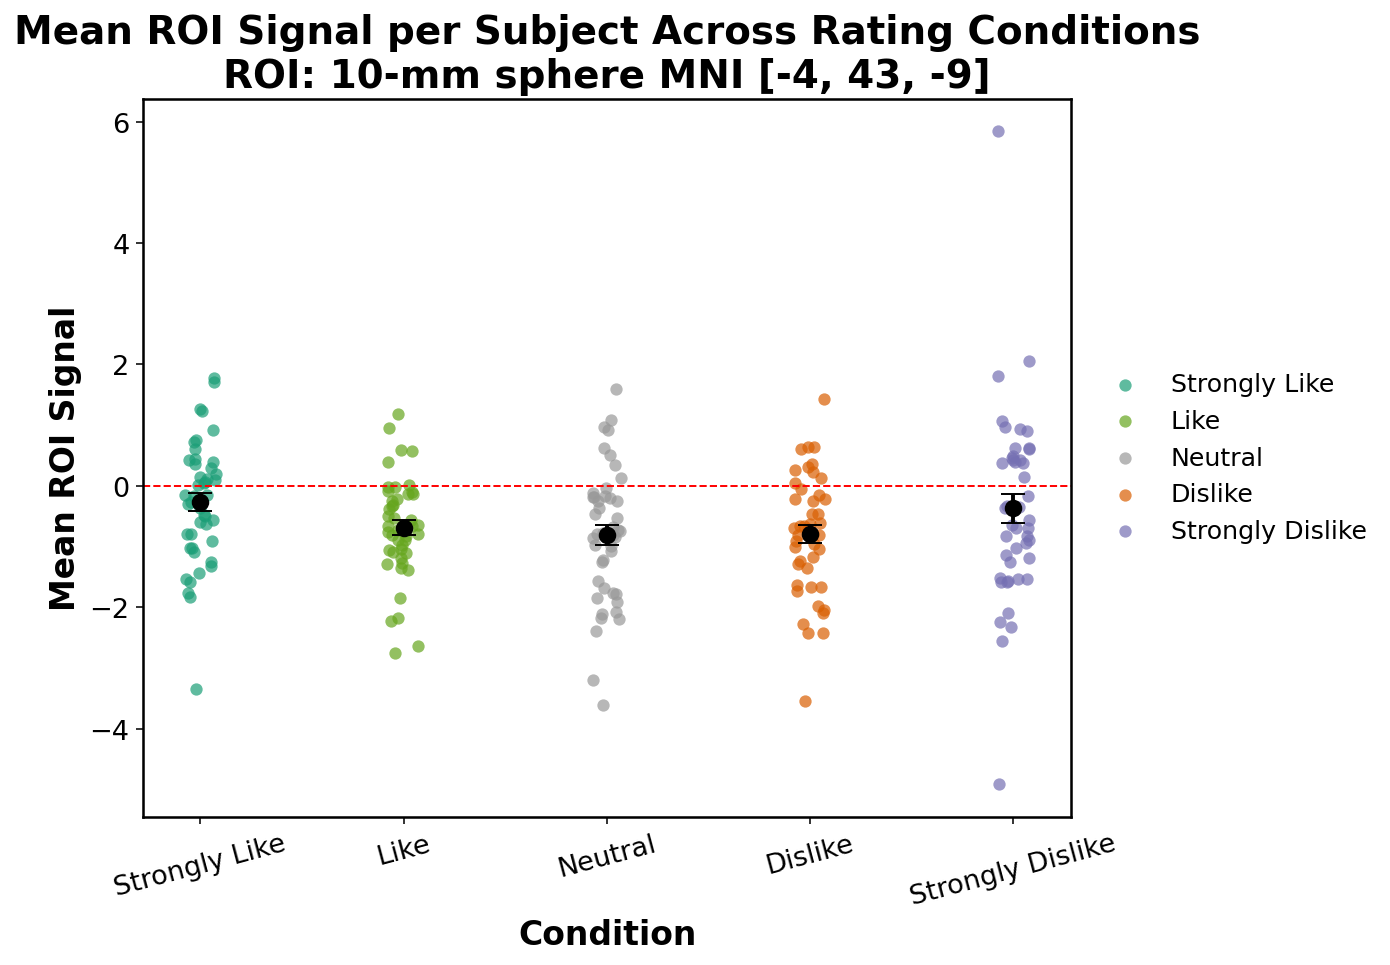

In [12]:
# --------------------------------------------------
# Plot 1: individual subject points + mean±SEM (NO pairwise brackets)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

for i, (condition, res) in enumerate(results.items(), start=1):
    y = np.asarray(res["mean_signal"], dtype=float)
    y = y[np.isfinite(y)]

    x = np.full(y.size, i, dtype=float)
    jitter = np.random.uniform(-0.08, 0.08, size=y.size)

    ax.scatter(
        x + jitter,
        y,
        color=condition_colors.get(condition, "black"),
        alpha=0.7,
        s=40,
        label=condition,
        linewidths=0,
    )

    ax.errorbar(
        x=i,
        y=res["mean"],
        yerr=res["sem"],
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=2,
        capsize=6,
        markersize=8,
    )

ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(1, len(results) + 1))
ax.set_xticklabels(list(results.keys()), rotation=15)

ax.set_ylabel("Mean ROI Signal", fontweight="bold")
ax.set_xlabel("Condition", fontweight="bold")
ax.set_title(
    f"Mean ROI Signal per Subject Across Rating Conditions\nROI: {ROI_LABEL_FOR_FIGS}",
    fontweight="bold"
)

ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
plt.tight_layout(rect=[0, 0, 0.82, 1])

# --- SAVE figure 1 ---
plot_title = "ScatterplotPerValue_NoPairwise"
fname = f"{roi_slug}_{plot_title}.jpeg"
out_path = os.path.join(FIG_DIR, fname)
plt.gcf().savefig(out_path, format="jpeg", dpi=600, bbox_inches="tight")
print(f"[OK] Saved: {out_path}")

plt.show()


## From atlas (exploratory)

In [20]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting, image

atlas_path = "/nfs/roberts/pi/pi_il77/shared/Neurosynth Parcellation_0.nii.gz"

# Load the image
img = nib.load(atlas_path)
print(f"Shape: {img.shape}")
print(f"Affine:\n{img.affine}")
data = img.get_fdata()
print(f"Unique parcels: {len(np.unique(data))} (including background 0)")
print(f"Parcel range: {int(data.min())} - {int(data.max())}")

Shape: (91, 109, 91)
Affine:
[[  -2.    0.    0.   90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
Unique parcels: 51 (including background 0)
Parcel range: 0 - 49


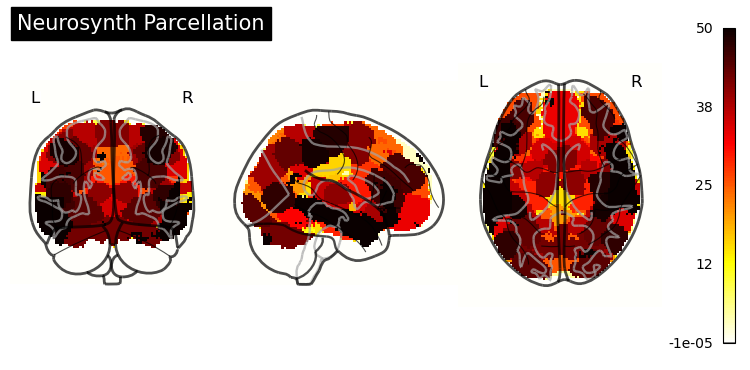

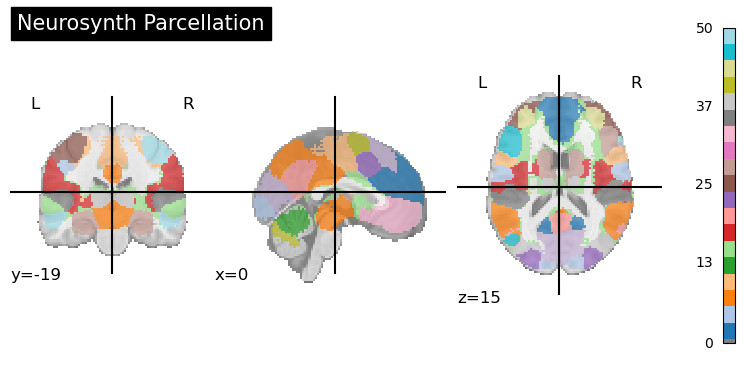

/home/acr69/.conda/envs/foodvaluation/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



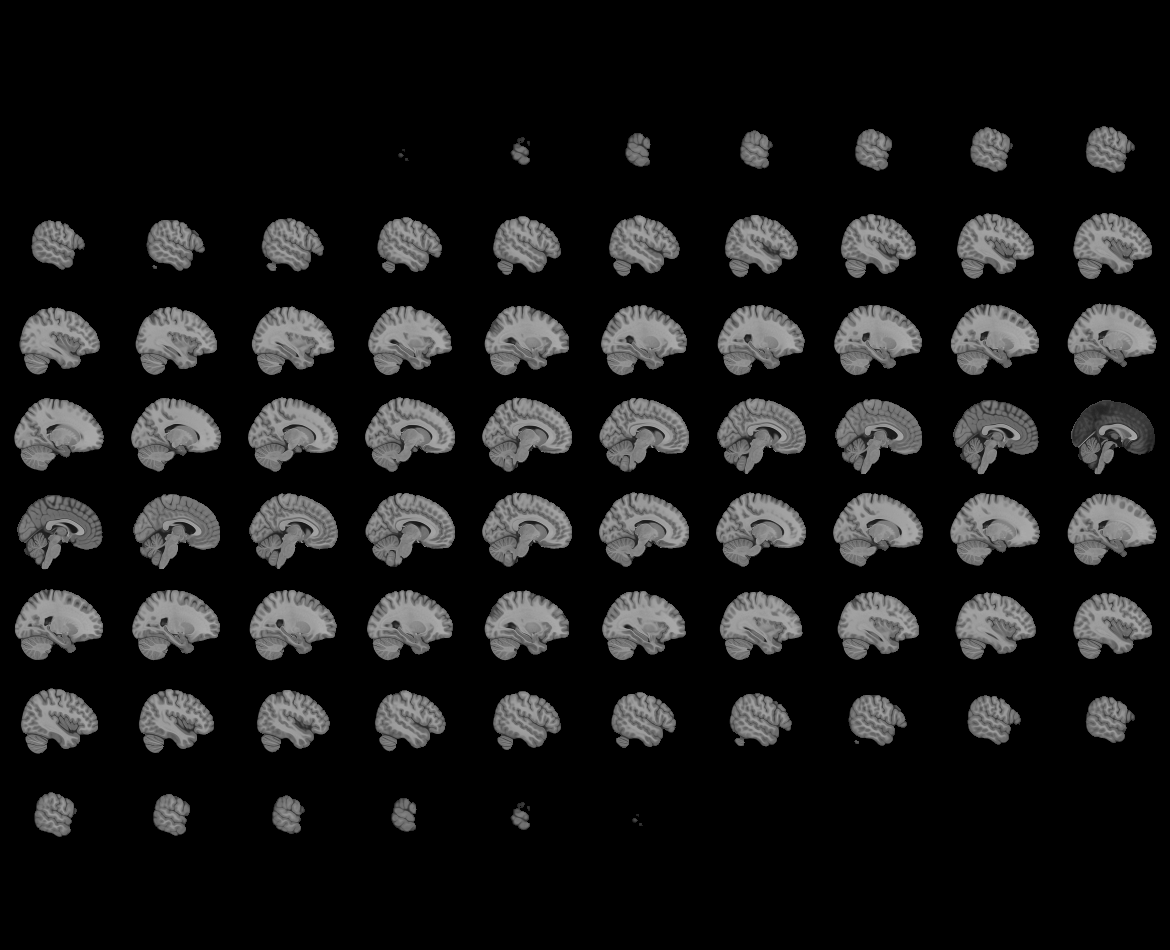
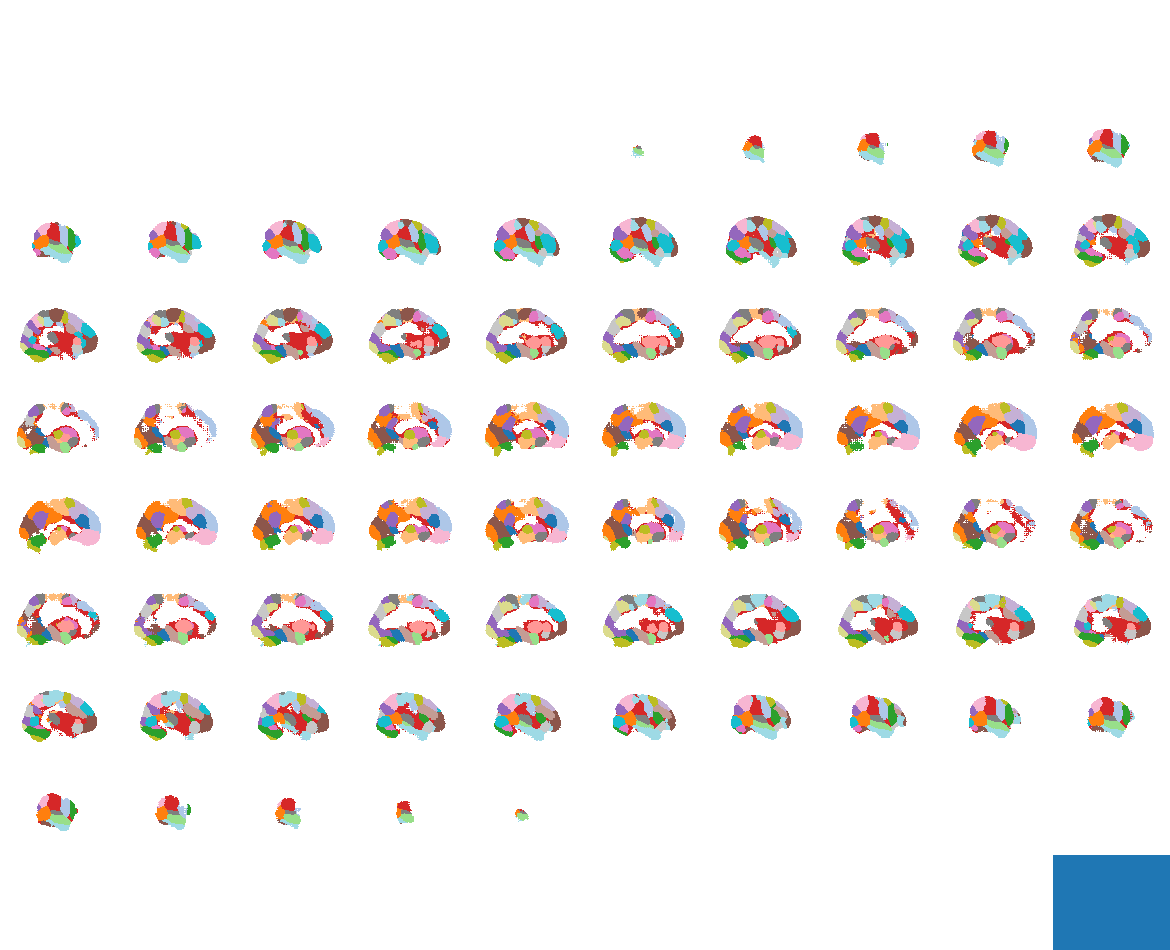

In [21]:
from nilearn import plotting

# Glass brain overview
plotting.plot_glass_brain(atlas_path, title="Neurosynth Parcellation", colorbar=True)
plt.show()

# Ortho slices (axial/coronal/sagittal)
plotting.plot_roi(atlas_path, title="Neurosynth Parcellation", colorbar=True,
                  cmap="tab20", alpha=0.7)
plt.show()

# Just use `view` directly as the last line of the cell — no .open_in_browser()
from nilearn import plotting

view = plotting.view_img(atlas_path, cmap="tab20", symmetric_cmap=False,
                         title="Neurosynth Parcellation")
view  # renders the interactive viewer inline in the notebook cell

In [22]:
# Corrected: file_value = your_label_id + 1
region_labels = {
    1:  "Anterior MPFC",
    2:  "Fusiform/Parahippocampus",
    3:  "DMPFC",
    4:  "Sensorimotor/Postcentral Gyrus",
    5:  "V1",
    6:  "TPJ Posterior SMG/Angular Gyrus",
    7:  "PCC/Precuneus",
    8:  "Thalamus",
    9:  "SMA",
    10: "Precentral Gyrus",
    11: "Cerebellum (VI)",
    12: "Temporal Occipital Fusiform",
    13: "Amygdala",
    14: "Superior Temporal Gyrus",
    15: "White Matter",
    16: "TPJ Anterior SMG/Parietal Operculum",
    17: "Mid Insula",
    18: "Putamen",
    19: "Dorsal Anterior Insula",
    20: "PCC/Superior LOC",
    21: "Lateral Occipital/Temporal Occipital (V2)",
    23: "dACC",
    24: "Anterior Fronto-Parietal (DLPFC, dACC)",
    25: "Intracalcarine Cortex",
    26: "Anterior VLPFC",
    28: "Left IFG",
    29: "Hippocampus",
    30: "Dorsal Caudate",
    31: "Unknown",
    33: "vmPFC",
    35: "NAcc",
    36: "Primary Auditory",
    38: "Ventral Anterior Insula",
    40: "Superior LOC",
    43: "Cerebellum (Crus)",
    45: "DLPFC",
    46: "Right IFG/VLPFC",
    47: "Inferior LOC",
    50: "STS"
}

# Updated frontal regions (file values)
frontal_regions = {
    1:  "Anterior MPFC",
    3:  "DMPFC",
    9:  "SMA",
    10: "Precentral Gyrus",
    23: "dACC",
    24: "Anterior Fronto-Parietal (DLPFC, dACC)",
    26: "Anterior VLPFC",
    28: "Left IFG",
    33: "vmPFC",
    45: "DLPFC",
    46: "Right IFG/VLPFC",
}

Region: vmPFC | file_value=33 | voxels=3591


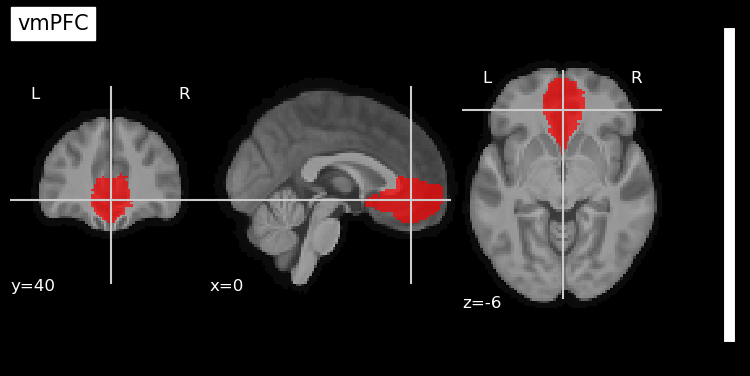

In [24]:
# Mask function
anat_img = load_img(str(MEAN_ANAT))

def make_parcel_mask(atlas_path, label_id):
    """label_id = your original 0-based label number"""
    img = nib.load(atlas_path)
    data = np.round(img.get_fdata()).astype(int)
    file_value = label_id + 1  # offset correction
    mask = (data == file_value).astype(np.int8)
    print(f"Region: {region_labels.get(file_value, 'Unknown')} | file_value={file_value} | voxels={mask.sum()}")
    return nib.Nifti1Image(mask, affine=img.affine)

# vmPFC
mask_img = make_parcel_mask(atlas_path, 32)  # your label 32 -> file value 33
plotting.plot_roi(mask_img, bg_img=anat_img, title="vmPFC", cmap="autumn", alpha=0.7)

/home/acr69/.conda/envs/foodvaluation/lib/python3.14/site-packages/joblib/memory.py:326: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  return self.func(*args, **kwargs)


[NiftiMasker.wrapped] Resampling images
Mean ROI Signal across all subjects: 0.03 ± 0.06
T-statistic: 3.211
P-value: 0.002


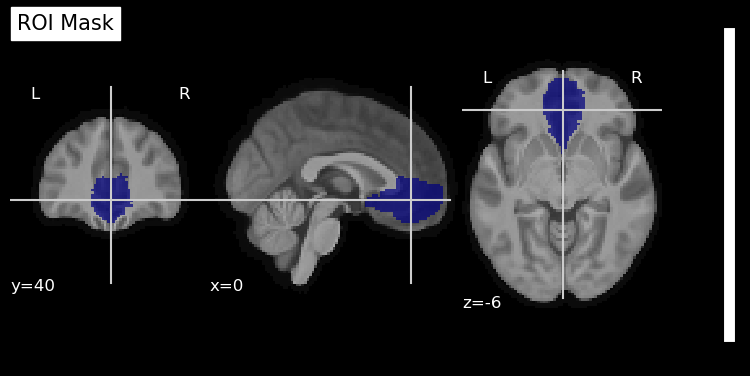

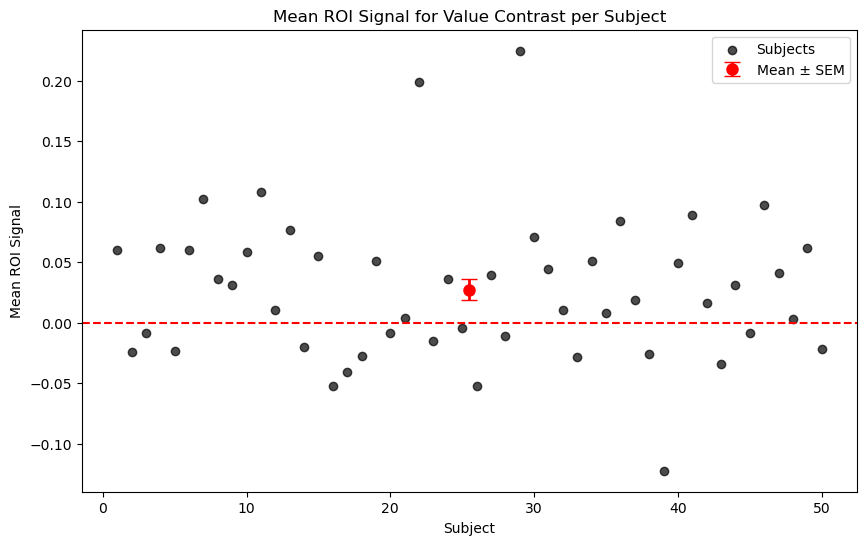

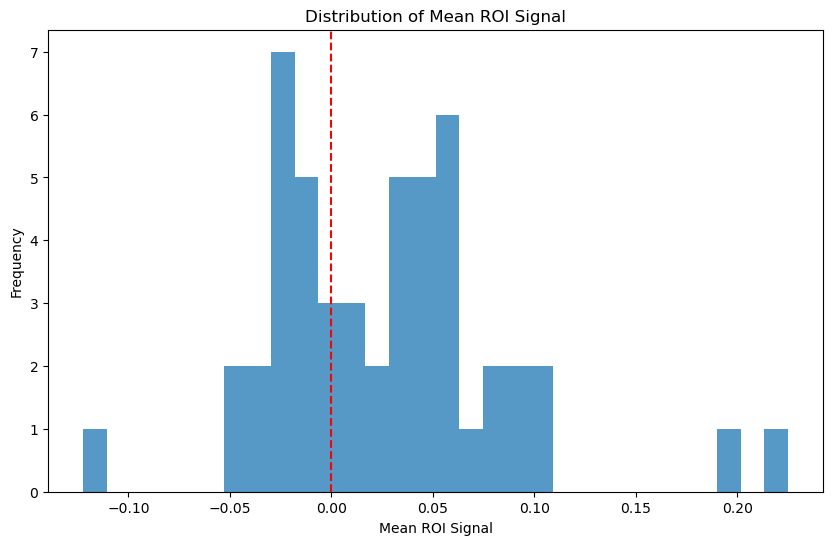

In [25]:
import os
import numpy as np
import nibabel as nib
from nilearn import input_data, plotting
from scipy import stats
import matplotlib.pyplot as plt

# Define paths
functional_img_path = os.path.join(OUTPUT_DIR, 'none_glm_Value_all_sub_4d.nii.gz')

# Load the functional image
functional_img = nib.load(functional_img_path)

# mask_img is already a Nifti1Image — use it directly, no nib.load() needed
roi_mask_img = mask_img

# Visualize the ROI on top of anatomical mean image (for verification)
plotting.plot_roi(roi_mask_img, anat_img, title='ROI Mask')

# Initialize the NiftiMasker for ROI mask
nifti_masker = input_data.NiftiMasker(mask_img=roi_mask_img)
nifti_masker.fit()

# Extract signal within the ROI (shape: n_subjects x n_voxels)
time_series = nifti_masker.transform(functional_img)

# Compute mean signal within the ROI for each subject
mean_signal_per_subject = time_series.mean(axis=1)

# Mean and SD across subjects
mean_signal = np.mean(mean_signal_per_subject)
std_signal = np.std(mean_signal_per_subject)
print(f"Mean ROI Signal across all subjects: {mean_signal:.2f} ± {std_signal:.2f}")

# One-sample t-test against 0
t_statistic, p_value = stats.ttest_1samp(mean_signal_per_subject, 0)
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Plotting individual subject points without connecting lines,
# plus group mean and error bar
plt.figure(figsize=(10, 6))

x_subjects = np.arange(1, len(mean_signal_per_subject) + 1)

# Individual subject points
plt.scatter(
    x_subjects,
    mean_signal_per_subject,
    color='black',
    alpha=0.7,
    label='Subjects'
)

# Mean and SEM
group_mean = np.mean(mean_signal_per_subject)
group_sem = stats.sem(mean_signal_per_subject)

# Plot mean as a red point with vertical error bar
plt.errorbar(
    x=np.mean(x_subjects),
    y=group_mean,
    yerr=group_sem,
    fmt='o',
    color='red',
    ecolor='red',
    elinewidth=2,
    capsize=6,
    markersize=8,
    label='Mean ± SEM'
)

plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Subject')
plt.ylabel('Mean ROI Signal')
plt.title('Mean ROI Signal for Value Contrast per Subject')
plt.legend()
plt.show()

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(mean_signal_per_subject, bins=30, alpha=0.75)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Mean ROI Signal')
plt.ylabel('Frequency')
plt.title('Distribution of Mean ROI Signal')
plt.show()